In [3]:
import pandas as pd
import numpy as np

# Path to the dataset
file_path = "default of credit card clients.xls"

# ------------------------------------------------------------
# Load the raw Excel file
# The UCI dataset contains extra header rows
# ------------------------------------------------------------

raw = pd.read_excel(file_path, header=None)

# Extract the correct column names (second row in file)
columns = raw.iloc[1].tolist()

# Extract actual data (starts on row 3)
df = raw.iloc[2:].copy()
df.columns = columns

# Reset index
df = df.reset_index(drop=True)

# ------------------------------------------------------------
# Convert columns to numeric
# ------------------------------------------------------------

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ------------------------------------------------------------
# Rename target variable
# ------------------------------------------------------------

df = df.rename(columns={"default payment next month": "default_next_month"})

# ------------------------------------------------------------
# Drop ID column (not useful for prediction)
# ------------------------------------------------------------

if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# ------------------------------------------------------------
# Display dataset summary
# ------------------------------------------------------------

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape:
(30000, 24)

Column names:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_next_month']

First 5 rows:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Missing values per column:
LIMIT_BAL             0
SEX                   0
EDUCATION             0
MARRIAGE              0
AGE                   0
PAY_0                 0
PAY_2                 0
PAY_3                 0
PAY_4                 0
PAY_5                 0
PAY_6                 0
BILL_AMT1             0
BILL_AMT2             0
BILL_AMT3             0
BILL_AMT4             0
BILL_AMT5             0
BILL_AMT6             0
PAY_AMT1              0
PAY_AMT2              0
PAY_AMT3              0
PAY_AMT4              0
PAY_AMT5              0
PAY_AMT6              0
default_next_month    0
dtype: int64


In [4]:
# ------------------------------------------------------------
# Inspect unique values before cleaning
# ------------------------------------------------------------

print("Unique values BEFORE cleaning:\n")

print("SEX:")
print(sorted(df["SEX"].dropna().unique()))

print("\nEDUCATION:")
print(sorted(df["EDUCATION"].dropna().unique()))

print("\nMARRIAGE:")
print(sorted(df["MARRIAGE"].dropna().unique()))

pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_cols:
    print(f"\n{col}:")
    print(sorted(df[col].dropna().unique()))

# ------------------------------------------------------------
# Clean known category quirks
# ------------------------------------------------------------

# EDUCATION:
# 1 = graduate school, 2 = university, 3 = high school
# Values 0, 5, 6 are usually treated as "other/unknown"
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE:
# 1 = married, 2 = single, 3 = other
# Value 0 is usually treated as "other"
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

# SEX is typically already valid in this dataset, so we leave it unchanged

# ------------------------------------------------------------
# Inspect unique values after cleaning
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Unique values AFTER cleaning:\n")

print("SEX:")
print(sorted(df["SEX"].dropna().unique()))

print("\nEDUCATION:")
print(sorted(df["EDUCATION"].dropna().unique()))

print("\nMARRIAGE:")
print(sorted(df["MARRIAGE"].dropna().unique()))

for col in pay_cols:
    print(f"\n{col}:")
    print(sorted(df[col].dropna().unique()))

# ------------------------------------------------------------
# Quick frequency tables for cleaned categorical variables
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Value counts for cleaned categorical variables:\n")

print("SEX value counts:")
print(df["SEX"].value_counts(dropna=False).sort_index())

print("\nEDUCATION value counts:")
print(df["EDUCATION"].value_counts(dropna=False).sort_index())

print("\nMARRIAGE value counts:")
print(df["MARRIAGE"].value_counts(dropna=False).sort_index())

Unique values BEFORE cleaning:

SEX:
[1, 2]

EDUCATION:
[0, 1, 2, 3, 4, 5, 6]

MARRIAGE:
[0, 1, 2, 3]

PAY_0:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_2:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_3:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_4:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_5:
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

PAY_6:
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

Unique values AFTER cleaning:

SEX:
[1, 2]

EDUCATION:
[1, 2, 3, 4]

MARRIAGE:
[1, 2, 3]

PAY_0:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_2:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_3:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_4:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_5:
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

PAY_6:
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

Value counts for cleaned categorical variables:

SEX value counts:
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION value counts:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE value counts:
MARRIAGE
1    13659
2    15964
3      377
N

In [7]:
# ------------------------------------------------------------
# Target variable
# ------------------------------------------------------------

y = df["default_next_month"].astype(int)

print("Target distribution:")
print(y.value_counts(normalize=True))

# ------------------------------------------------------------
# Demographic / static features
# ------------------------------------------------------------

demographic_cols = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE"
]

# ------------------------------------------------------------
# 6-month history columns
# ------------------------------------------------------------

pay_cols_full = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

bill_cols_full = [
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6"
]

pay_amt_cols_full = [
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"
]

# ------------------------------------------------------------
# 3-month history
# ------------------------------------------------------------

pay_cols_3m = ["PAY_0","PAY_2","PAY_3"]

bill_cols_3m = ["BILL_AMT1","BILL_AMT2","BILL_AMT3"]

pay_amt_cols_3m = ["PAY_AMT1","PAY_AMT2","PAY_AMT3"]

# ------------------------------------------------------------
# 1-month history
# ------------------------------------------------------------

pay_cols_1m = ["PAY_0"]

bill_cols_1m = ["BILL_AMT1"]

pay_amt_cols_1m = ["PAY_AMT1"]

# ------------------------------------------------------------
# Raw feature matrices
# ------------------------------------------------------------

X_1m_raw = df[demographic_cols + pay_cols_1m + bill_cols_1m + pay_amt_cols_1m].copy()

X_3m_raw = df[demographic_cols + pay_cols_3m + bill_cols_3m + pay_amt_cols_3m].copy()

X_6m_raw = df[demographic_cols + pay_cols_full + bill_cols_full + pay_amt_cols_full].copy()

# ------------------------------------------------------------
# Print shapes
# ------------------------------------------------------------

print("\nFeature matrix shapes:")

print("1-month features:", X_1m_raw.shape)
print("3-month features:", X_3m_raw.shape)
print("6-month features:", X_6m_raw.shape)

print("\nTarget shape:", y.shape)

Target distribution:
default_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Feature matrix shapes:
1-month features: (30000, 8)
3-month features: (30000, 14)
6-month features: (30000, 23)

Target shape: (30000,)


In [8]:
def build_summary_features(df_in, pay_cols, bill_cols, pay_amt_cols):
    X = df_in.copy()

    # ------------------------------------------------------------
    # Repayment behavior
    # ------------------------------------------------------------
    X["pay_max"] = X[pay_cols].max(axis=1)
    X["pay_mean"] = X[pay_cols].mean(axis=1)
    X["num_delinq_ge1"] = (X[pay_cols] >= 1).sum(axis=1)
    X["num_delinq_ge2"] = (X[pay_cols] >= 2).sum(axis=1)
    X["num_clean_months"] = (X[pay_cols] <= 0).sum(axis=1)

    # ------------------------------------------------------------
    # Delinquency trend / worsening
    # For this dataset, the first column in each chosen window is the
    # most recent month and the last is the oldest month.
    # ------------------------------------------------------------
    worsening_count = np.zeros(len(X), dtype=int)
    for i in range(len(pay_cols) - 1):
        worsening_count += (X[pay_cols[i]] > X[pay_cols[i + 1]]).astype(int)

    X["delinq_worsening_count"] = worsening_count
    X["delinq_recent_minus_old"] = X[pay_cols[0]] - X[pay_cols[-1]]

    # ------------------------------------------------------------
    # Bill behavior
    # ------------------------------------------------------------
    X["bill_max"] = X[bill_cols].max(axis=1)
    X["bill_mean"] = X[bill_cols].mean(axis=1)
    X["bill_std"] = X[bill_cols].std(axis=1).fillna(0)
    X["bill_recent_minus_old"] = X[bill_cols[0]] - X[bill_cols[-1]]

    # ------------------------------------------------------------
    # Utilization proxy: bill / credit limit
    # Protect against divide-by-zero
    # ------------------------------------------------------------
    limit_safe = X["LIMIT_BAL"].replace(0, np.nan)

    util_df = X[bill_cols].div(limit_safe, axis=0)
    X["util_mean_proxy"] = util_df.mean(axis=1)
    X["util_max_proxy"] = util_df.max(axis=1)
    X["util_recent_proxy"] = X[bill_cols[0]] / limit_safe

    # Replace any inf / nan created by division
    util_cols = ["util_mean_proxy", "util_max_proxy", "util_recent_proxy"]
    X[util_cols] = X[util_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    # ------------------------------------------------------------
    # Payment behavior
    # ------------------------------------------------------------
    X["pay_amt_total"] = X[pay_amt_cols].sum(axis=1)
    X["pay_amt_mean"] = X[pay_amt_cols].mean(axis=1)
    X["pay_amt_std"] = X[pay_amt_cols].std(axis=1).fillna(0)

    # ------------------------------------------------------------
    # Payment-rate features: payment / bill
    # Use absolute bill and floor denominator at 1 for safety
    # ------------------------------------------------------------
    rate_cols = []
    for bcol, pcol in zip(bill_cols, pay_amt_cols):
        rate_name = f"{pcol}_over_{bcol}"
        denom = np.maximum(X[bcol].abs(), 1)
        X[rate_name] = X[pcol] / denom
        X[rate_name] = X[rate_name].replace([np.inf, -np.inf], np.nan).fillna(0)
        rate_cols.append(rate_name)

    X["payment_rate_mean"] = X[rate_cols].mean(axis=1)
    X["payment_rate_min"] = X[rate_cols].min(axis=1)
    X["payment_rate_recent"] = X[rate_cols[0]]

    # ------------------------------------------------------------
    # Recent bill-payment gap
    # ------------------------------------------------------------
    X["recent_bill_minus_payment"] = X[bill_cols[0]] - X[pay_amt_cols[0]]

    return X


# ------------------------------------------------------------
# Build summary-feature datasets for each time window
# ------------------------------------------------------------

X_1m_sum = build_summary_features(
    X_1m_raw,
    pay_cols_1m,
    bill_cols_1m,
    pay_amt_cols_1m
)

X_3m_sum = build_summary_features(
    X_3m_raw,
    pay_cols_3m,
    bill_cols_3m,
    pay_amt_cols_3m
)

X_6m_sum = build_summary_features(
    X_6m_raw,
    pay_cols_full,
    bill_cols_full,
    pay_amt_cols_full
)

# ------------------------------------------------------------
# Display summary info
# ------------------------------------------------------------

print("Summary feature matrix shapes:")
print("X_1m_sum:", X_1m_sum.shape)
print("X_3m_sum:", X_3m_sum.shape)
print("X_6m_sum:", X_6m_sum.shape)

print("\nExample engineered columns:")
engineered_cols = [
    "pay_max",
    "pay_mean",
    "num_delinq_ge1",
    "num_delinq_ge2",
    "delinq_worsening_count",
    "delinq_recent_minus_old",
    "bill_max",
    "bill_mean",
    "util_mean_proxy",
    "util_max_proxy",
    "pay_amt_total",
    "payment_rate_mean",
    "payment_rate_min",
    "payment_rate_recent",
    "recent_bill_minus_payment"
]

print([col for col in engineered_cols if col in X_6m_sum.columns])

print("\nPreview of engineered 6-month feature set:")
display(X_6m_sum.head())

Summary feature matrix shapes:
X_1m_sum: (30000, 30)
X_3m_sum: (30000, 38)
X_6m_sum: (30000, 50)

Example engineered columns:
['pay_max', 'pay_mean', 'num_delinq_ge1', 'num_delinq_ge2', 'delinq_worsening_count', 'delinq_recent_minus_old', 'bill_max', 'bill_mean', 'util_mean_proxy', 'util_max_proxy', 'pay_amt_total', 'payment_rate_mean', 'payment_rate_min', 'payment_rate_recent', 'recent_bill_minus_payment']

Preview of engineered 6-month feature set:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT1_over_BILL_AMT1,PAY_AMT2_over_BILL_AMT2,PAY_AMT3_over_BILL_AMT3,PAY_AMT4_over_BILL_AMT4,PAY_AMT5_over_BILL_AMT5,PAY_AMT6_over_BILL_AMT6,payment_rate_mean,payment_rate_min,payment_rate_recent,recent_bill_minus_payment
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0.000000,0.222115,0.000000,0.000000,0.000000,0.000000,0.037019,0.000000,0.000000,3913
1,120000,2,2,2,26,-1,2,0,0,0,...,0.000000,0.579710,0.372856,0.305623,0.000000,0.613309,0.311916,0.000000,0.000000,2682
2,90000,2,2,2,34,0,0,0,0,0,...,0.051917,0.106937,0.073752,0.069779,0.066899,0.321564,0.115141,0.051917,0.051917,27721
3,50000,2,2,1,37,0,0,0,0,0,...,0.042562,0.041859,0.024345,0.038850,0.036914,0.033844,0.036396,0.024345,0.042562,44990
4,50000,1,2,1,57,-1,0,-1,0,0,...,0.232099,6.469312,0.279057,0.429799,0.035987,0.035492,1.246958,0.035492,0.232099,6617


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# Train/test split
# use the 6-month summary-feature dataset for the first model
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_6m_sum,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain default rate:")
print(y_train.mean())

print("\nTest default rate:")
print(y_test.mean())

# ------------------------------------------------------------
# Identify categorical and numeric columns
# ------------------------------------------------------------

categorical_cols = [col for col in ["SEX", "EDUCATION", "MARRIAGE"] if col in X_train.columns]
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numeric columns:")
print(len(numeric_cols))

# ------------------------------------------------------------
# Preprocessing pipelines
# ------------------------------------------------------------

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# ------------------------------------------------------------
# Logistic regression pipeline
# ------------------------------------------------------------

logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

# ------------------------------------------------------------
# Fit the model
# ------------------------------------------------------------

logit_model.fit(X_train, y_train)

print("\nLogistic regression pipeline fitted successfully.")

# ------------------------------------------------------------
# Generate predictions for the test set
# ------------------------------------------------------------

y_test_proba = logit_model.predict_proba(X_test)[:, 1]
y_test_pred = logit_model.predict(X_test)

print("\nFirst 10 predicted probabilities:")
print(y_test_proba[:10])

print("\nFirst 10 predicted class labels:")
print(y_test_pred[:10])

X_train shape: (24000, 50)
X_test shape: (6000, 50)
y_train shape: (24000,)
y_test shape: (6000,)

Train default rate:
0.22120833333333334

Test default rate:
0.22116666666666668

Categorical columns:
['SEX', 'EDUCATION', 'MARRIAGE']

Number of numeric columns:
47

Logistic regression pipeline fitted successfully.

First 10 predicted probabilities:
[0.33253423 0.46651301 0.38541172 0.24543653 0.18659737 0.58722677
 0.25378798 0.14867936 0.18334303 0.27238131]

First 10 predicted class labels:
[0 0 0 0 0 1 0 0 0 0]


Logistic Regression Test Metrics:

ROC_AUC: 0.7559
PR_AUC: 0.5180
Accuracy: 0.7422
Precision: 0.4398
Recall: 0.6051
F1: 0.5094
Confusion_Matrix:
[[3650 1023]
 [ 524  803]]

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.78      0.83      4673
           1       0.44      0.61      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.74      0.76      6000



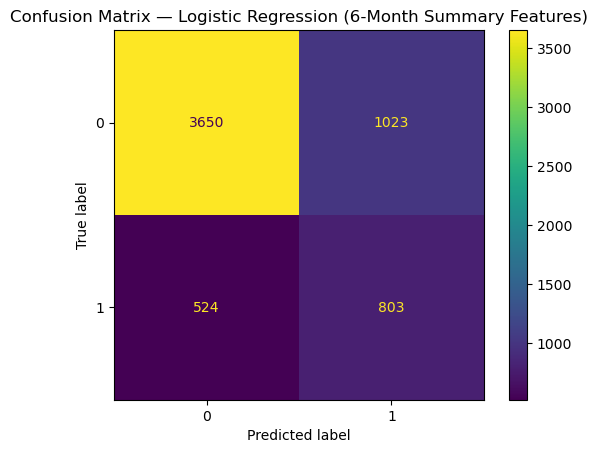

In [10]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------

def evaluate_binary_model(y_true, y_proba, threshold=0.50):
    y_pred = (y_proba >= threshold).astype(int)

    metrics_dict = {
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Confusion_Matrix": confusion_matrix(y_true, y_pred)
    }

    return metrics_dict, y_pred


# ------------------------------------------------------------
# Evaluate current model on the held-out test set
# ------------------------------------------------------------

metrics_dict, y_pred_eval = evaluate_binary_model(y_test, y_test_proba, threshold=0.50)

print("Logistic Regression Test Metrics:\n")
for metric, value in metrics_dict.items():
    if metric != "Confusion_Matrix":
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}:\n{value}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_eval, zero_division=0))

# ------------------------------------------------------------
# Confusion matrix plot
# ------------------------------------------------------------

disp = ConfusionMatrixDisplay(confusion_matrix=metrics_dict["Confusion_Matrix"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (6-Month Summary Features)")
plt.show()

In [11]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# ------------------------------------------------------------
# Hyperparameter tuning function
# ------------------------------------------------------------

def tune_logistic_regression(X, y):    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )
    
    # Identify categorical and numeric columns
    categorical_cols = [col for col in ["SEX", "EDUCATION", "MARRIAGE"] if col in X.columns]
    numeric_cols = [col for col in X.columns if col not in categorical_cols]
    
    # Preprocessing
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )
    
    # Base pipeline
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ])
    
    # Hyperparameter grid
    param_grid = {
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 5, 10, 20]
    }
    
    # Cross-validation setup
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Grid search
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    
    # Fit
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    # Held-out test evaluation
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= 0.50).astype(int)
    
    results = {
        "best_params": grid.best_params_,
        "ROC_AUC": roc_auc_score(y_test, y_test_proba),
        "PR_AUC": average_precision_score(y_test, y_test_proba),
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "F1": f1_score(y_test, y_test_pred, zero_division=0),
        "Confusion_Matrix": confusion_matrix(y_test, y_test_pred)
    }
    
    return best_model, results


# ------------------------------------------------------------
# Tune on 6-month summary features first
# ------------------------------------------------------------

best_logit_6m, results_6m = tune_logistic_regression(X_6m_sum, y)

print("Best 6-Month Logistic Regression Results:\n")
print("Best Parameters:", results_6m["best_params"])
print(f"ROC_AUC:   {results_6m['ROC_AUC']:.4f}")
print(f"PR_AUC:    {results_6m['PR_AUC']:.4f}")
print(f"Accuracy:  {results_6m['Accuracy']:.4f}")
print(f"Precision: {results_6m['Precision']:.4f}")
print(f"Recall:    {results_6m['Recall']:.4f}")
print(f"F1:        {results_6m['F1']:.4f}")
print("Confusion Matrix:\n", results_6m["Confusion_Matrix"])

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 

Best 6-Month Logistic Regression Results:

Best Parameters: {'model__C': 0.1, 'model__penalty': 'l1'}
ROC_AUC:   0.7558
PR_AUC:    0.5174
Accuracy:  0.7432
Precision: 0.4413
Recall:    0.6066
F1:        0.5109
Confusion Matrix:
 [[3654 1019]
 [ 522  805]]


Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

Comparison of Tuned Logistic Regression Models Across Time Windows:



,window,best_penalty,best_C,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1
0,3 months,l1,1.0,0.7571,0.5156,0.7672,0.4777,0.5659,0.5181
1,6 months,l1,0.1,0.7558,0.5174,0.7432,0.4413,0.6066,0.5109
2,1 month,l1,1.0,0.7337,0.4917,0.7730,0.4872,0.5034,0.4952


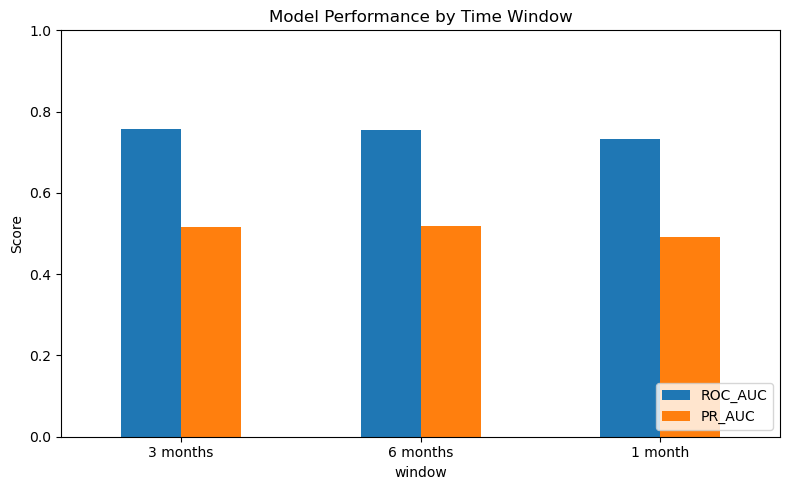

In [12]:
# ------------------------------------------------------------
# Train tuned logistic regression on each time window
# ------------------------------------------------------------

best_logit_1m, results_1m = tune_logistic_regression(X_1m_sum, y)
best_logit_3m, results_3m = tune_logistic_regression(X_3m_sum, y)
best_logit_6m, results_6m = tune_logistic_regression(X_6m_sum, y)

# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------

comparison_rows = [
    {
        "window": "1 month",
        "best_penalty": results_1m["best_params"]["model__penalty"],
        "best_C": results_1m["best_params"]["model__C"],
        "ROC_AUC": results_1m["ROC_AUC"],
        "PR_AUC": results_1m["PR_AUC"],
        "Accuracy": results_1m["Accuracy"],
        "Precision": results_1m["Precision"],
        "Recall": results_1m["Recall"],
        "F1": results_1m["F1"]
    },
    {
        "window": "3 months",
        "best_penalty": results_3m["best_params"]["model__penalty"],
        "best_C": results_3m["best_params"]["model__C"],
        "ROC_AUC": results_3m["ROC_AUC"],
        "PR_AUC": results_3m["PR_AUC"],
        "Accuracy": results_3m["Accuracy"],
        "Precision": results_3m["Precision"],
        "Recall": results_3m["Recall"],
        "F1": results_3m["F1"]
    },
    {
        "window": "6 months",
        "best_penalty": results_6m["best_params"]["model__penalty"],
        "best_C": results_6m["best_params"]["model__C"],
        "ROC_AUC": results_6m["ROC_AUC"],
        "PR_AUC": results_6m["PR_AUC"],
        "Accuracy": results_6m["Accuracy"],
        "Precision": results_6m["Precision"],
        "Recall": results_6m["Recall"],
        "F1": results_6m["F1"]
    }
]

results_df = pd.DataFrame(comparison_rows)
results_df = results_df.sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Comparison of Tuned Logistic Regression Models Across Time Windows:\n")
display(results_df.round(4))

# ------------------------------------------------------------
# Plot ROC-AUC and PR-AUC by time window
# ------------------------------------------------------------

plot_df = results_df.set_index("window")[["ROC_AUC", "PR_AUC"]]

ax = plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Model Performance by Time Window")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [13]:
# ------------------------------------------------------------
# Evaluate simple traditional risk rules against the target
# ------------------------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rule_results = []

# Rule 1: Any recent delinquency
pred_recent_any_delinquency = (df["PAY_0"] >= 1).astype(int)

rule_results.append({
    "rule": "recent_any_delinquency (PAY_0 >= 1)",
    "Accuracy": accuracy_score(y, pred_recent_any_delinquency),
    "Precision": precision_score(y, pred_recent_any_delinquency, zero_division=0),
    "Recall": recall_score(y, pred_recent_any_delinquency, zero_division=0),
    "F1": f1_score(y, pred_recent_any_delinquency, zero_division=0)
})

# Rule 2: Severe recent delinquency
pred_recent_severe_delinquency = (df["PAY_0"] >= 2).astype(int)

rule_results.append({
    "rule": "recent_severe_delinquency (PAY_0 >= 2)",
    "Accuracy": accuracy_score(y, pred_recent_severe_delinquency),
    "Precision": precision_score(y, pred_recent_severe_delinquency, zero_division=0),
    "Recall": recall_score(y, pred_recent_severe_delinquency, zero_division=0),
    "F1": f1_score(y, pred_recent_severe_delinquency, zero_division=0)
})

# Rule 3: High utilization proxy
util_recent = df["BILL_AMT1"] / np.maximum(df["LIMIT_BAL"], 1)
pred_high_util = (util_recent >= 0.80).astype(int)

rule_results.append({
    "rule": "high_utilization_proxy (BILL_AMT1 / LIMIT_BAL >= 0.8)",
    "Accuracy": accuracy_score(y, pred_high_util),
    "Precision": precision_score(y, pred_high_util, zero_division=0),
    "Recall": recall_score(y, pred_high_util, zero_division=0),
    "F1": f1_score(y, pred_high_util, zero_division=0)
})

# Rule 4: Low recent payment rate
payment_rate_recent = df["PAY_AMT1"] / np.maximum(df["BILL_AMT1"].abs(), 1)
pred_low_payment_rate = (payment_rate_recent < 0.10).astype(int)

rule_results.append({
    "rule": "low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1| < 0.1)",
    "Accuracy": accuracy_score(y, pred_low_payment_rate),
    "Precision": precision_score(y, pred_low_payment_rate, zero_division=0),
    "Recall": recall_score(y, pred_low_payment_rate, zero_division=0),
    "F1": f1_score(y, pred_low_payment_rate, zero_division=0)
})

# ------------------------------------------------------------
# Build and display results table
# ------------------------------------------------------------

rule_results_df = pd.DataFrame(rule_results)
rule_results_df = rule_results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

print("Traditional Rule-Based Baseline Results:\n")
display(rule_results_df.round(4))

Traditional Rule-Based Baseline Results:



,rule,Accuracy,Precision,Recall,F1
0,recent_any_delinquency (PAY_0 >= 1),0.7801,0.5029,0.5167,0.5097
1,recent_severe_delinquency (PAY_0 >= 2),0.8196,0.6955,0.3281,0.4458
2,low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1...,0.4668,0.2477,0.6924,0.3649
3,high_utilization_proxy (BILL_AMT1 / LIMIT_BAL ...,0.6550,0.2673,0.3214,0.2919


In [14]:
# ------------------------------------------------------------
# Recreate the same train/test split used inside tune_logistic_regression
# ------------------------------------------------------------

X_train_6m, X_test_6m, y_train_6m, y_test_6m = train_test_split(
    X_6m_sum,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Corresponding original rows from df for the same held-out test set
df_train_6m, df_test_6m = train_test_split(
    df,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# Get predicted probabilities from the tuned 6-month logistic model
# ------------------------------------------------------------

test_probs_6m = best_logit_6m.predict_proba(X_test_6m)[:, 1]

# ------------------------------------------------------------
# Filter to the non-obvious-risk subset: PAY_0 < 2
# ------------------------------------------------------------

non_obvious_mask = df_test_6m["PAY_0"] < 2

X_test_non_obvious = X_test_6m.loc[non_obvious_mask]
y_test_non_obvious = y_test_6m.loc[non_obvious_mask]
probs_non_obvious = test_probs_6m[non_obvious_mask.values]

# ------------------------------------------------------------
# Evaluate the model on this subset
# ------------------------------------------------------------

subset_size = len(y_test_non_obvious)
subset_default_rate = y_test_non_obvious.mean()

subset_roc_auc = roc_auc_score(y_test_non_obvious, probs_non_obvious)
subset_pr_auc = average_precision_score(y_test_non_obvious, probs_non_obvious)

print("Early-Warning Test on Non-Obvious-Risk Accounts")
print("=" * 55)
print(f"Subset definition: PAY_0 < 2")
print(f"Subset size: {subset_size}")
print(f"Subset default rate: {subset_default_rate:.4f}")
print(f"Subset ROC-AUC: {subset_roc_auc:.4f}")
print(f"Subset PR-AUC: {subset_pr_auc:.4f}")

# ------------------------------------------------------------
# Compare against a simple traditional rule inside the same subset
# ------------------------------------------------------------

# Traditional rule: recent severe delinquency (PAY_0 >= 2)
# Inside this subset, that rule predicts all zeros by definition.
traditional_rule_preds = np.zeros(len(y_test_non_obvious), dtype=int)

trad_accuracy = accuracy_score(y_test_non_obvious, traditional_rule_preds)
trad_precision = precision_score(y_test_non_obvious, traditional_rule_preds, zero_division=0)
trad_recall = recall_score(y_test_non_obvious, traditional_rule_preds, zero_division=0)
trad_f1 = f1_score(y_test_non_obvious, traditional_rule_preds, zero_division=0)

print("\nTraditional severe-delinquency rule within this subset")
print("-" * 55)
print("Rule: predict default if PAY_0 >= 2")
print("Since all accounts here have PAY_0 < 2, the rule predicts no defaults.")
print(f"Accuracy:  {trad_accuracy:.4f}")
print(f"Precision: {trad_precision:.4f}")
print(f"Recall:    {trad_recall:.4f}")
print(f"F1:        {trad_f1:.4f}")

# ------------------------------------------------------------
# Simple interpretation
# ------------------------------------------------------------

print("\nInterpretation:")
if subset_roc_auc > 0.65:
    print(
        "The logistic regression model retains meaningful predictive power even "
        "among accounts without an obvious current delinquency spike. This supports "
        "the early-warning hypothesis."
    )
else:
    print(
        "The model shows limited discrimination in the non-obvious-risk subset, "
        "so evidence for early warning is weaker."
    )

Early-Warning Test on Non-Obvious-Risk Accounts
Subset definition: PAY_0 < 2
Subset size: 5364
Subset default rate: 0.1655
Subset ROC-AUC: 0.6754
Subset PR-AUC: 0.3058

Traditional severe-delinquency rule within this subset
-------------------------------------------------------
Rule: predict default if PAY_0 >= 2
Since all accounts here have PAY_0 < 2, the rule predicts no defaults.
Accuracy:  0.8345
Precision: 0.0000
Recall:    0.0000
F1:        0.0000

Interpretation:
The logistic regression model retains meaningful predictive power even among accounts without an obvious current delinquency spike. This supports the early-warning hypothesis.


In [15]:
def get_logistic_feature_importance(fitted_pipeline):
    # Pull out fitted pieces
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]
    
    # Get transformed feature names
    feature_names = preprocessor.get_feature_names_out()
    
    # Logistic coefficients for binary classification
    coefs = model.coef_[0]
    
    # Build DataFrame
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs)
    }).sort_values(by="abs_coefficient", ascending=False).reset_index(drop=True)
    
    return coef_df

# ------------------------------------------------------------
# Extract coefficients from the tuned 6-month model
# ------------------------------------------------------------

coef_df = get_logistic_feature_importance(best_logit_6m)

print("Top 20 most influential features in the tuned 6-month logistic model:\n")
display(coef_df.head(20).round(4))

# ------------------------------------------------------------
# Separate positive and negative drivers
# ------------------------------------------------------------

top_positive = coef_df.sort_values(by="coefficient", ascending=False).head(10).reset_index(drop=True)
top_negative = coef_df.sort_values(by="coefficient", ascending=True).head(10).reset_index(drop=True)

print("\nTop 10 positive predictors of default:\n")
display(top_positive.round(4))

print("\nTop 10 negative predictors of default:\n")
display(top_negative.round(4))

Top 20 most influential features in the tuned 6-month logistic model:



,feature,coefficient,abs_coefficient
0,num__num_delinq_ge2,1.1760,1.1760
1,cat__EDUCATION_4,-0.7674,0.7674
2,num__pay_amt_std,0.4199,0.4199
3,num__pay_max,0.3753,0.3753
4,num__pay_amt_total,-0.3469,0.3469
5,num__PAY_3,-0.2080,0.2080
6,num__bill_max,-0.2044,0.2044
7,num__delinq_recent_minus_old,0.1982,0.1982
8,num__LIMIT_BAL,-0.1955,0.1955
9,num__num_clean_months,0.1940,0.1940



Top 10 positive predictors of default:



,feature,coefficient,abs_coefficient
0,num__num_delinq_ge2,1.1760,1.1760
1,num__pay_amt_std,0.4199,0.4199
2,num__pay_max,0.3753,0.3753
3,num__delinq_recent_minus_old,0.1982,0.1982
4,num__num_clean_months,0.1940,0.1940
5,num__util_mean_proxy,0.1704,0.1704
6,num__BILL_AMT3,0.1447,0.1447
7,num__BILL_AMT2,0.1287,0.1287
8,num__AGE,0.0385,0.0385
9,num__bill_recent_minus_old,0.0353,0.0353



Top 10 negative predictors of default:



,feature,coefficient,abs_coefficient
0,cat__EDUCATION_4,-0.7674,0.7674
1,num__pay_amt_total,-0.3469,0.3469
2,num__PAY_3,-0.2080,0.2080
3,num__bill_max,-0.2044,0.2044
4,num__LIMIT_BAL,-0.1955,0.1955
5,num__PAY_4,-0.1573,0.1573
6,num__pay_amt_mean,-0.1527,0.1527
7,num__PAY_2,-0.1462,0.1462
8,cat__SEX_2,-0.1434,0.1434
9,cat__MARRIAGE_2,-0.1398,0.1398


Final model comparison table:



,model_type,model_name,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1
0,Logistic Regression,3-month summary features,0.7571,0.5156,0.7672,0.4777,0.5659,0.5181
1,Logistic Regression,6-month summary features,0.7558,0.5174,0.7432,0.4413,0.6066,0.5109
2,Logistic Regression,1-month summary features,0.7337,0.4917,0.7730,0.4872,0.5034,0.4952
3,Traditional Rule,recent_any_delinquency (PAY_0 >= 1),NaN,NaN,0.7801,0.5029,0.5167,0.5097
4,Traditional Rule,recent_severe_delinquency (PAY_0 >= 2),NaN,NaN,0.8196,0.6955,0.3281,0.4458
5,Traditional Rule,low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1...,NaN,NaN,0.4668,0.2477,0.6924,0.3649
6,Traditional Rule,high_utilization_proxy (BILL_AMT1 / LIMIT_BAL ...,NaN,NaN,0.6550,0.2673,0.3214,0.2919


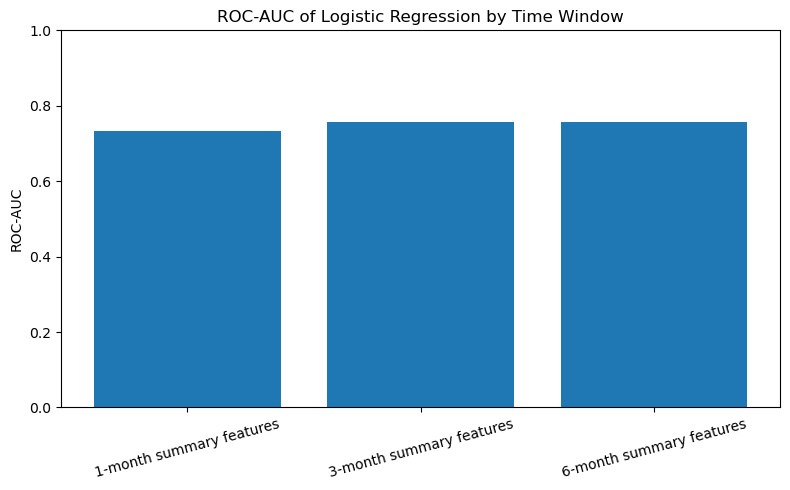

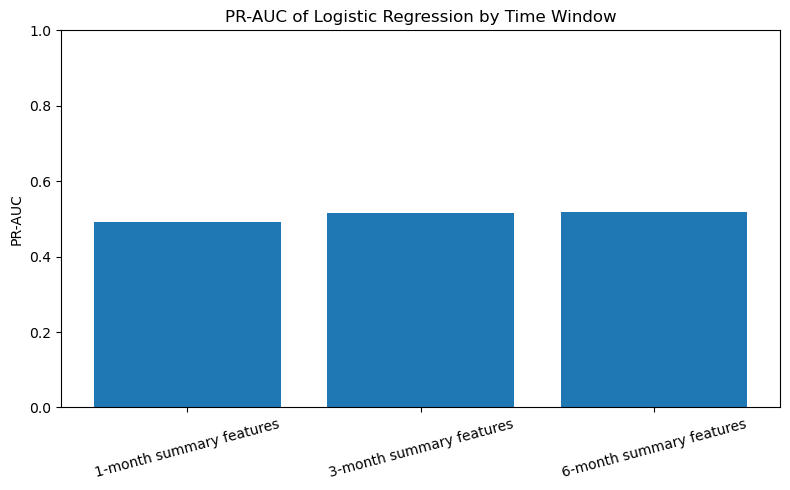

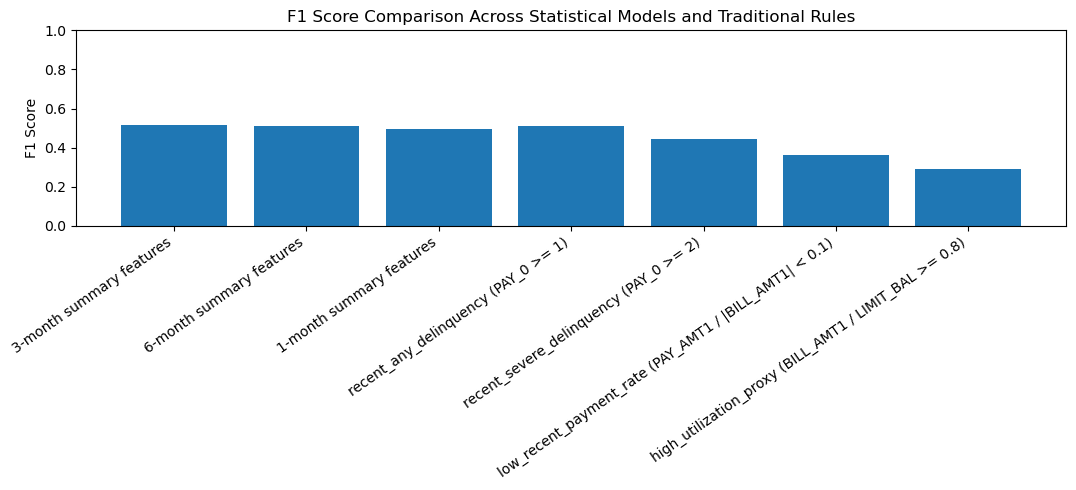

In [16]:
# ------------------------------------------------------------
# Build logistic-model results table
# ------------------------------------------------------------

logit_summary_rows = [
    {
        "model_type": "Logistic Regression",
        "model_name": "1-month summary features",
        "ROC_AUC": results_1m["ROC_AUC"],
        "PR_AUC": results_1m["PR_AUC"],
        "Accuracy": results_1m["Accuracy"],
        "Precision": results_1m["Precision"],
        "Recall": results_1m["Recall"],
        "F1": results_1m["F1"]
    },
    {
        "model_type": "Logistic Regression",
        "model_name": "3-month summary features",
        "ROC_AUC": results_3m["ROC_AUC"],
        "PR_AUC": results_3m["PR_AUC"],
        "Accuracy": results_3m["Accuracy"],
        "Precision": results_3m["Precision"],
        "Recall": results_3m["Recall"],
        "F1": results_3m["F1"]
    },
    {
        "model_type": "Logistic Regression",
        "model_name": "6-month summary features",
        "ROC_AUC": results_6m["ROC_AUC"],
        "PR_AUC": results_6m["PR_AUC"],
        "Accuracy": results_6m["Accuracy"],
        "Precision": results_6m["Precision"],
        "Recall": results_6m["Recall"],
        "F1": results_6m["F1"]
    }
]

logit_summary_df = pd.DataFrame(logit_summary_rows)

# ------------------------------------------------------------
# Add placeholder ROC_AUC / PR_AUC columns to rule baselines
# since those rule outputs are hard class predictions, not scores
# ------------------------------------------------------------

rule_summary_df = rule_results_df.copy()
rule_summary_df["model_type"] = "Traditional Rule"
rule_summary_df = rule_summary_df.rename(columns={"rule": "model_name"})
rule_summary_df["ROC_AUC"] = np.nan
rule_summary_df["PR_AUC"] = np.nan

rule_summary_df = rule_summary_df[
    ["model_type", "model_name", "ROC_AUC", "PR_AUC", "Accuracy", "Precision", "Recall", "F1"]
]

# ------------------------------------------------------------
# Combine into one final table
# ------------------------------------------------------------

final_results_df = pd.concat(
    [logit_summary_df, rule_summary_df],
    axis=0,
    ignore_index=True
)

final_results_df = final_results_df.sort_values(
    by=["model_type", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

print("Final model comparison table:\n")
display(final_results_df.round(4))

# ------------------------------------------------------------
# Plot 1: Logistic regression ROC-AUC across time windows
# ------------------------------------------------------------

logit_plot_df = logit_summary_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(logit_plot_df["model_name"], logit_plot_df["ROC_AUC"])
plt.title("ROC-AUC of Logistic Regression by Time Window")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: Logistic regression PR-AUC across time windows
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.bar(logit_plot_df["model_name"], logit_plot_df["PR_AUC"])
plt.title("PR-AUC of Logistic Regression by Time Window")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 3: F1 score comparison across all models/rules
# ------------------------------------------------------------

plt.figure(figsize=(11, 5))
plt.bar(final_results_df["model_name"], final_results_df["F1"])
plt.title("F1 Score Comparison Across Statistical Models and Traditional Rules")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [17]:
from sklearn.neighbors import KNeighborsClassifier

def tune_knn(X, y):
    """
    Tune a k-NN classifier using GridSearchCV with the same
    preprocessing structure used for logistic regression.
    """
    
    # ------------------------------------------------------------
    # Train/test split
    # ------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )
    
    # ------------------------------------------------------------
    # Identify categorical and numeric columns
    # ------------------------------------------------------------
    categorical_cols = [col for col in ["SEX", "EDUCATION", "MARRIAGE"] if col in X.columns]
    numeric_cols = [col for col in X.columns if col not in categorical_cols]
    
    # ------------------------------------------------------------
    # Preprocessing
    # ------------------------------------------------------------
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )
    
    # ------------------------------------------------------------
    # Pipeline
    # ------------------------------------------------------------
    knn_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ])
    
    # ------------------------------------------------------------
    # Hyperparameter grid
    # ------------------------------------------------------------
    param_grid = {
        "model__n_neighbors": [5, 11, 21, 31],
        "model__weights": ["uniform", "distance"]
    }
    
    # ------------------------------------------------------------
    # Cross-validation
    # ------------------------------------------------------------
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    grid = GridSearchCV(
        estimator=knn_pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    
    # ------------------------------------------------------------
    # Fit
    # ------------------------------------------------------------
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    # ------------------------------------------------------------
    # Evaluate on held-out test set
    # ------------------------------------------------------------
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= 0.50).astype(int)
    
    results = {
        "best_params": grid.best_params_,
        "ROC_AUC": roc_auc_score(y_test, y_test_proba),
        "PR_AUC": average_precision_score(y_test, y_test_proba),
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "F1": f1_score(y_test, y_test_pred, zero_division=0),
        "Confusion_Matrix": confusion_matrix(y_test, y_test_pred)
    }
    
    return best_model, results

# ------------------------------------------------------------
# Train and evaluate k-NN on the 6-month summary features
# ------------------------------------------------------------

best_knn_6m, knn_results_6m = tune_knn(X_6m_sum, y)

print("Best 6-Month k-NN Results:\n")
print("Best Parameters:", knn_results_6m["best_params"])
print(f"ROC_AUC:   {knn_results_6m['ROC_AUC']:.4f}")
print(f"PR_AUC:    {knn_results_6m['PR_AUC']:.4f}")
print(f"Accuracy:  {knn_results_6m['Accuracy']:.4f}")
print(f"Precision: {knn_results_6m['Precision']:.4f}")
print(f"Recall:    {knn_results_6m['Recall']:.4f}")
print(f"F1:        {knn_results_6m['F1']:.4f}")
print("Confusion Matrix:\n", knn_results_6m["Confusion_Matrix"])

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best 6-Month k-NN Results:

Best Parameters: {'model__n_neighbors': 31, 'model__weights': 'uniform'}
ROC_AUC:   0.7544
PR_AUC:    0.5122
Accuracy:  0.8147
Precision: 0.6435
Recall:    0.3632
F1:        0.4644
Confusion Matrix:
 [[4406  267]
 [ 845  482]]


Final comparison table including k-NN:



,model_type,model_name,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1
0,Logistic Regression,3-month summary features,0.7571,0.5156,0.7672,0.4777,0.5659,0.5181
1,Logistic Regression,6-month summary features,0.7558,0.5174,0.7432,0.4413,0.6066,0.5109
2,k-NN,6-month summary features,0.7544,0.5122,0.8147,0.6435,0.3632,0.4644
3,Logistic Regression,1-month summary features,0.7337,0.4917,0.7730,0.4872,0.5034,0.4952
4,Traditional Rule,recent_any_delinquency (PAY_0 >= 1),NaN,NaN,0.7801,0.5029,0.5167,0.5097
5,Traditional Rule,recent_severe_delinquency (PAY_0 >= 2),NaN,NaN,0.8196,0.6955,0.3281,0.4458
6,Traditional Rule,low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1...,NaN,NaN,0.4668,0.2477,0.6924,0.3649
7,Traditional Rule,high_utilization_proxy (BILL_AMT1 / LIMIT_BAL ...,NaN,NaN,0.6550,0.2673,0.3214,0.2919


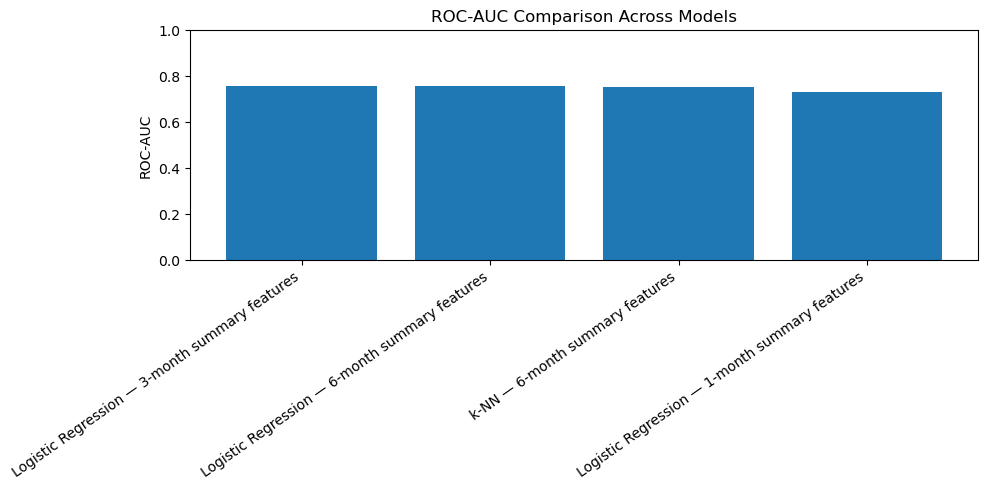

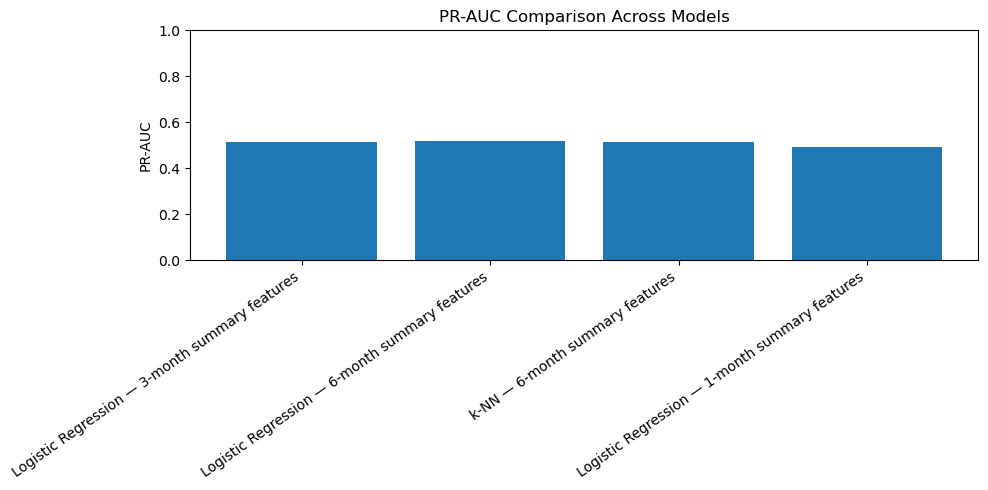

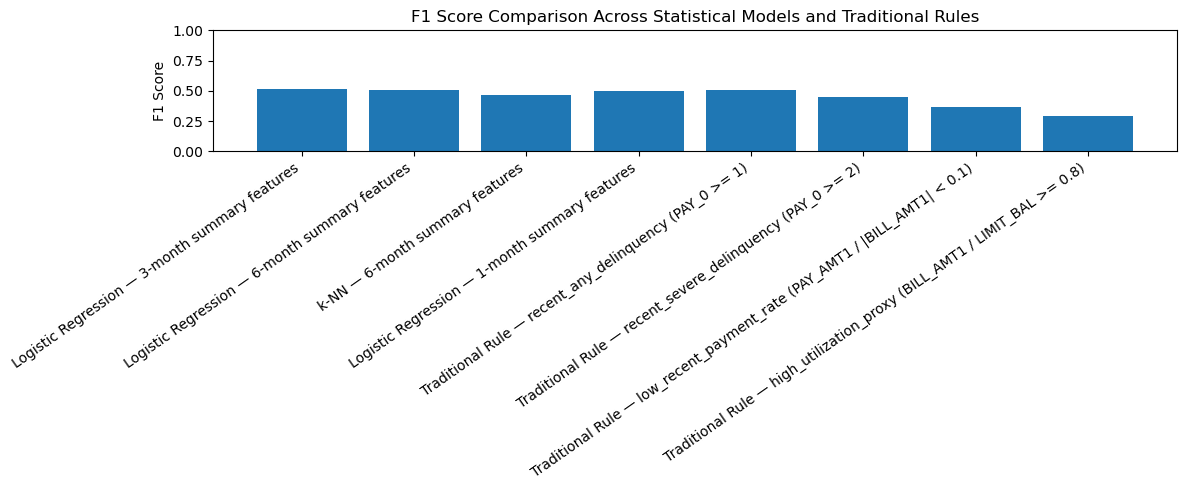

In [18]:
# ------------------------------------------------------------
# Create a one-row DataFrame for k-NN results
# ------------------------------------------------------------

knn_summary_row = pd.DataFrame([
    {
        "model_type": "k-NN",
        "model_name": "6-month summary features",
        "ROC_AUC": knn_results_6m["ROC_AUC"],
        "PR_AUC": knn_results_6m["PR_AUC"],
        "Accuracy": knn_results_6m["Accuracy"],
        "Precision": knn_results_6m["Precision"],
        "Recall": knn_results_6m["Recall"],
        "F1": knn_results_6m["F1"]
    }
])

# ------------------------------------------------------------
# Append k-NN to the existing final results table
# ------------------------------------------------------------

final_results_with_knn_df = pd.concat(
    [final_results_df, knn_summary_row],
    axis=0,
    ignore_index=True
)

final_results_with_knn_df = final_results_with_knn_df.sort_values(
    by=["ROC_AUC", "F1"],
    ascending=[False, False],
    na_position="last"
).reset_index(drop=True)

print("Final comparison table including k-NN:\n")
display(final_results_with_knn_df.round(4))

# ------------------------------------------------------------
# Plot 1: ROC-AUC comparison across models with score outputs
# ------------------------------------------------------------

roc_plot_df = final_results_with_knn_df.dropna(subset=["ROC_AUC"]).copy()

plt.figure(figsize=(10, 5))
plt.bar(roc_plot_df["model_type"] + " — " + roc_plot_df["model_name"], roc_plot_df["ROC_AUC"])
plt.title("ROC-AUC Comparison Across Models")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: PR-AUC comparison across models with score outputs
# ------------------------------------------------------------

pr_plot_df = final_results_with_knn_df.dropna(subset=["PR_AUC"]).copy()

plt.figure(figsize=(10, 5))
plt.bar(pr_plot_df["model_type"] + " — " + pr_plot_df["model_name"], pr_plot_df["PR_AUC"])
plt.title("PR-AUC Comparison Across Models")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 3: F1 comparison across all models and rules
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.bar(
    final_results_with_knn_df["model_type"] + " — " + final_results_with_knn_df["model_name"],
    final_results_with_knn_df["F1"]
)
plt.title("F1 Score Comparison Across Statistical Models and Traditional Rules")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

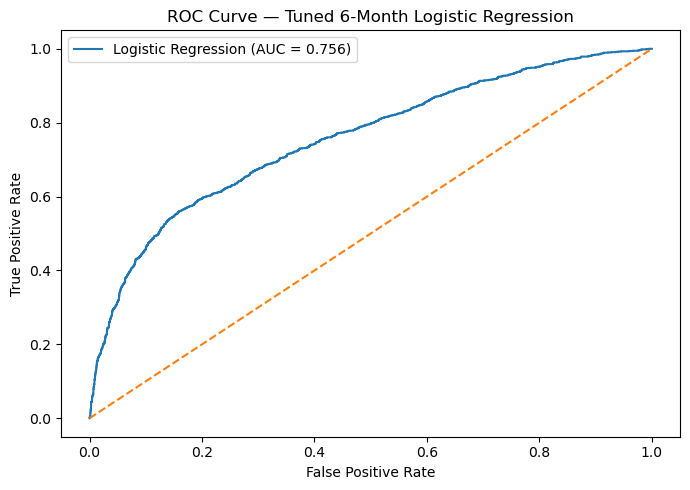

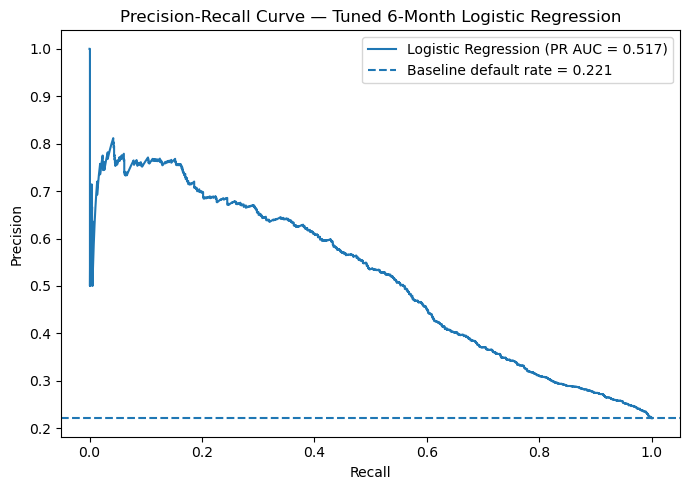

Top-Decile Lift Analysis
Test-set default rate: 0.2212
Top 10% score-group default rate: 0.6583
Lift at top 10%: 2.9766
Defaults captured in top 10%: 395
Total defaults in test set: 1327
Capture rate in top 10%: 0.2977

Decile summary (1 = highest-risk decile):


,decile,accounts,defaults,default_rate,avg_score
0,1,600,395,0.6583,0.8829
1,2,600,259,0.4317,0.7038
2,3,600,146,0.2433,0.5716
3,4,600,112,0.1867,0.4455
4,5,600,97,0.1617,0.3817
5,6,600,79,0.1317,0.3499
6,7,600,87,0.1450,0.3235
7,8,600,68,0.1133,0.2931
8,9,600,56,0.0933,0.2516
9,10,600,28,0.0467,0.1704


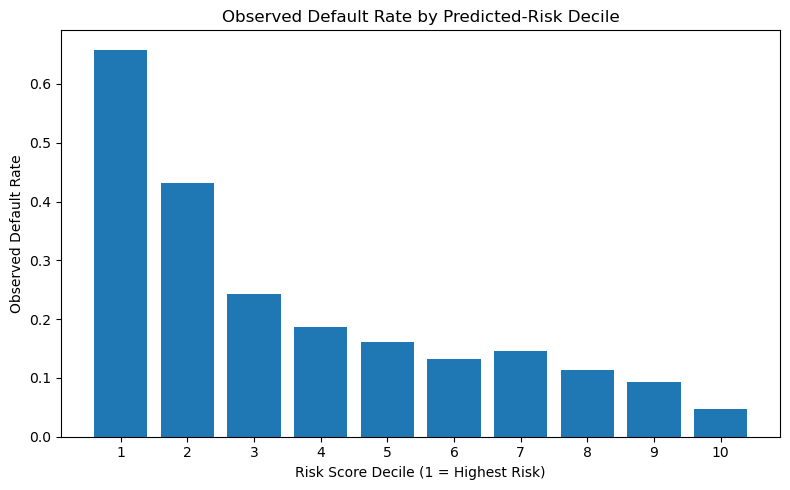

In [19]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ------------------------------------------------------------
# Recreate the held-out test set for the tuned 6-month model
# ------------------------------------------------------------

X_train_6m, X_test_6m, y_train_6m, y_test_6m = train_test_split(
    X_6m_sum,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Predicted probabilities from best tuned logistic model
y_score_6m = best_logit_6m.predict_proba(X_test_6m)[:, 1]

# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(y_test_6m, y_score_6m)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned 6-Month Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Precision-recall curve
# ------------------------------------------------------------

precision_vals, recall_vals, _ = precision_recall_curve(y_test_6m, y_score_6m)
pr_auc_val = auc(recall_vals, precision_vals)
baseline_rate = y_test_6m.mean()

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, label=f"Logistic Regression (PR AUC = {pr_auc_val:.3f})")
plt.axhline(baseline_rate, linestyle="--", label=f"Baseline default rate = {baseline_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Tuned 6-Month Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Top-decile lift / capture analysis
# ------------------------------------------------------------

lift_df = pd.DataFrame({
    "y_true": y_test_6m.values,
    "score": y_score_6m
}).sort_values("score", ascending=False).reset_index(drop=True)

n = len(lift_df)
top_10_n = int(np.ceil(0.10 * n))

top_decile = lift_df.iloc[:top_10_n]

overall_default_rate = lift_df["y_true"].mean()
top_decile_default_rate = top_decile["y_true"].mean()
lift_at_10 = top_decile_default_rate / overall_default_rate if overall_default_rate > 0 else np.nan

defaults_captured_top10 = top_decile["y_true"].sum()
total_defaults = lift_df["y_true"].sum()
capture_rate_top10 = defaults_captured_top10 / total_defaults if total_defaults > 0 else np.nan

print("Top-Decile Lift Analysis")
print("=" * 40)
print(f"Test-set default rate: {overall_default_rate:.4f}")
print(f"Top 10% score-group default rate: {top_decile_default_rate:.4f}")
print(f"Lift at top 10%: {lift_at_10:.4f}")
print(f"Defaults captured in top 10%: {int(defaults_captured_top10)}")
print(f"Total defaults in test set: {int(total_defaults)}")
print(f"Capture rate in top 10%: {capture_rate_top10:.4f}")

# ------------------------------------------------------------
# Decile table
# ------------------------------------------------------------

lift_df["decile"] = pd.qcut(
    lift_df["score"].rank(method="first", ascending=False),
    10,
    labels=[1,2,3,4,5,6,7,8,9,10]
)

decile_summary = lift_df.groupby("decile").agg(
    accounts=("y_true", "size"),
    defaults=("y_true", "sum"),
    default_rate=("y_true", "mean"),
    avg_score=("score", "mean")
).reset_index()

print("\nDecile summary (1 = highest-risk decile):")
display(decile_summary.round(4))

# ------------------------------------------------------------
# Plot default rate by score decile
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.bar(decile_summary["decile"].astype(str), decile_summary["default_rate"])
plt.xlabel("Risk Score Decile (1 = Highest Risk)")
plt.ylabel("Observed Default Rate")
plt.title("Observed Default Rate by Predicted-Risk Decile")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/miniconda3/envs/engs106/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

Fitting 5 folds for each of 12 candidates, totalling 60 fits


...

feature_type,raw,summary
window,,
1 month,0.7023,0.7337
3 months,0.7100,0.7571
6 months,0.7103,0.7558



PR-AUC comparison:


feature_type,raw,summary
window,,
1 month,0.4835,0.4917
3 months,0.4899,0.5156
6 months,0.4913,0.5174



F1 comparison:


feature_type,raw,summary
window,,
1 month,0.4562,0.4952
3 months,0.4641,0.5181
6 months,0.4649,0.5109


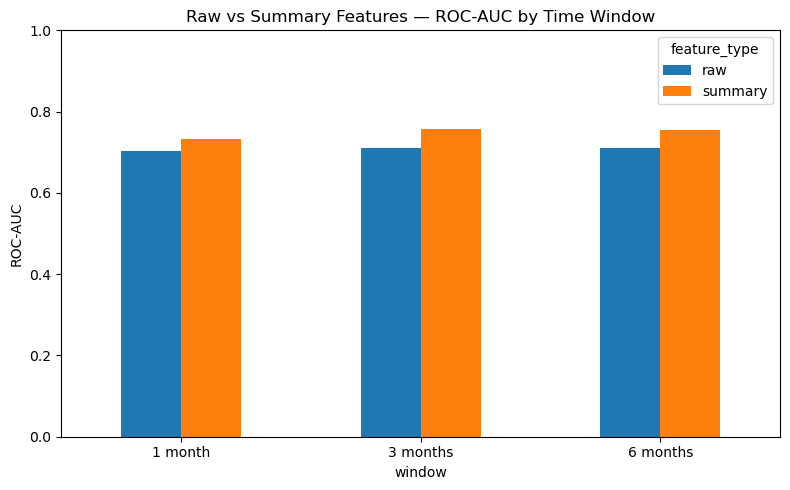

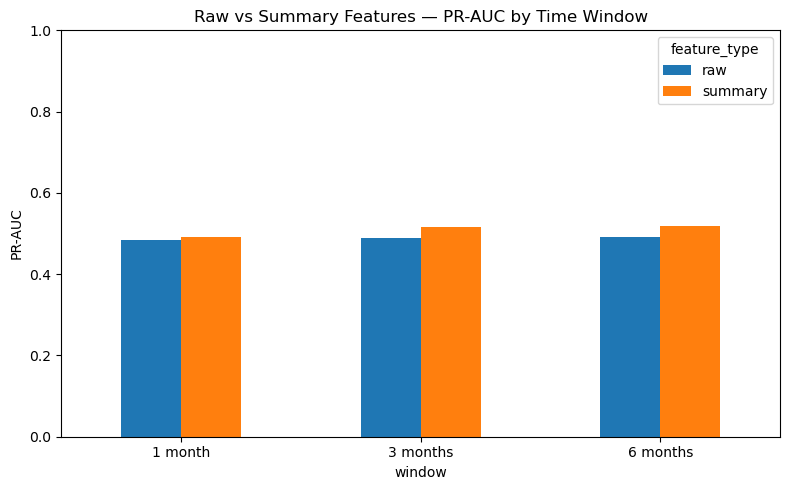

In [20]:
comparison_feature_rows = []

# ------------------------------------------------------------
# 1-month comparison
# ------------------------------------------------------------

best_logit_1m_raw, results_1m_raw = tune_logistic_regression(X_1m_raw, y)
best_logit_1m_sum, results_1m_sum = tune_logistic_regression(X_1m_sum, y)

comparison_feature_rows.append({
    "window": "1 month",
    "feature_type": "raw",
    "best_penalty": results_1m_raw["best_params"]["model__penalty"],
    "best_C": results_1m_raw["best_params"]["model__C"],
    "ROC_AUC": results_1m_raw["ROC_AUC"],
    "PR_AUC": results_1m_raw["PR_AUC"],
    "Accuracy": results_1m_raw["Accuracy"],
    "Precision": results_1m_raw["Precision"],
    "Recall": results_1m_raw["Recall"],
    "F1": results_1m_raw["F1"]
})

comparison_feature_rows.append({
    "window": "1 month",
    "feature_type": "summary",
    "best_penalty": results_1m_sum["best_params"]["model__penalty"],
    "best_C": results_1m_sum["best_params"]["model__C"],
    "ROC_AUC": results_1m_sum["ROC_AUC"],
    "PR_AUC": results_1m_sum["PR_AUC"],
    "Accuracy": results_1m_sum["Accuracy"],
    "Precision": results_1m_sum["Precision"],
    "Recall": results_1m_sum["Recall"],
    "F1": results_1m_sum["F1"]
})

# ------------------------------------------------------------
# 3-month comparison
# ------------------------------------------------------------

best_logit_3m_raw, results_3m_raw = tune_logistic_regression(X_3m_raw, y)
best_logit_3m_sum, results_3m_sum = tune_logistic_regression(X_3m_sum, y)

comparison_feature_rows.append({
    "window": "3 months",
    "feature_type": "raw",
    "best_penalty": results_3m_raw["best_params"]["model__penalty"],
    "best_C": results_3m_raw["best_params"]["model__C"],
    "ROC_AUC": results_3m_raw["ROC_AUC"],
    "PR_AUC": results_3m_raw["PR_AUC"],
    "Accuracy": results_3m_raw["Accuracy"],
    "Precision": results_3m_raw["Precision"],
    "Recall": results_3m_raw["Recall"],
    "F1": results_3m_raw["F1"]
})

comparison_feature_rows.append({
    "window": "3 months",
    "feature_type": "summary",
    "best_penalty": results_3m_sum["best_params"]["model__penalty"],
    "best_C": results_3m_sum["best_params"]["model__C"],
    "ROC_AUC": results_3m_sum["ROC_AUC"],
    "PR_AUC": results_3m_sum["PR_AUC"],
    "Accuracy": results_3m_sum["Accuracy"],
    "Precision": results_3m_sum["Precision"],
    "Recall": results_3m_sum["Recall"],
    "F1": results_3m_sum["F1"]
})

# ------------------------------------------------------------
# 6-month comparison
# ------------------------------------------------------------

best_logit_6m_raw, results_6m_raw = tune_logistic_regression(X_6m_raw, y)
best_logit_6m_sum, results_6m_sum = tune_logistic_regression(X_6m_sum, y)

comparison_feature_rows.append({
    "window": "6 months",
    "feature_type": "raw",
    "best_penalty": results_6m_raw["best_params"]["model__penalty"],
    "best_C": results_6m_raw["best_params"]["model__C"],
    "ROC_AUC": results_6m_raw["ROC_AUC"],
    "PR_AUC": results_6m_raw["PR_AUC"],
    "Accuracy": results_6m_raw["Accuracy"],
    "Precision": results_6m_raw["Precision"],
    "Recall": results_6m_raw["Recall"],
    "F1": results_6m_raw["F1"]
})

comparison_feature_rows.append({
    "window": "6 months",
    "feature_type": "summary",
    "best_penalty": results_6m_sum["best_params"]["model__penalty"],
    "best_C": results_6m_sum["best_params"]["model__C"],
    "ROC_AUC": results_6m_sum["ROC_AUC"],
    "PR_AUC": results_6m_sum["PR_AUC"],
    "Accuracy": results_6m_sum["Accuracy"],
    "Precision": results_6m_sum["Precision"],
    "Recall": results_6m_sum["Recall"],
    "F1": results_6m_sum["F1"]
})

# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------

raw_vs_summary_df = pd.DataFrame(comparison_feature_rows)

print("Raw vs Summary Feature Comparison:\n")
display(raw_vs_summary_df.round(4))

# ------------------------------------------------------------
# Pivot tables for easier comparison
# ------------------------------------------------------------

roc_pivot = raw_vs_summary_df.pivot(index="window", columns="feature_type", values="ROC_AUC")
pr_pivot = raw_vs_summary_df.pivot(index="window", columns="feature_type", values="PR_AUC")
f1_pivot = raw_vs_summary_df.pivot(index="window", columns="feature_type", values="F1")

print("\nROC-AUC comparison:")
display(roc_pivot.round(4))

print("\nPR-AUC comparison:")
display(pr_pivot.round(4))

print("\nF1 comparison:")
display(f1_pivot.round(4))

# ------------------------------------------------------------
# Plot ROC-AUC comparison
# ------------------------------------------------------------

roc_pivot.plot(kind="bar", figsize=(8, 5))
plt.title("Raw vs Summary Features — ROC-AUC by Time Window")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot PR-AUC comparison
# ------------------------------------------------------------

pr_pivot.plot(kind="bar", figsize=(8, 5))
plt.title("Raw vs Summary Features — PR-AUC by Time Window")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Threshold tuning table:



,threshold,Accuracy,Precision,Recall,F1
0,0.10,0.2315,0.2233,0.9985,0.3650
1,0.15,0.2463,0.2262,0.9947,0.3686
2,0.20,0.2802,0.2337,0.9894,0.3781
3,0.25,0.3488,0.2487,0.9623,0.3953
4,0.30,0.4482,0.2738,0.9050,0.4204
5,0.35,0.5775,0.3171,0.7890,0.4524
6,0.40,0.6785,0.3762,0.6895,0.4868
7,0.45,0.7178,0.4108,0.6353,0.4990
8,0.50,0.7432,0.4413,0.6066,0.5109
9,0.55,0.7645,0.4734,0.5757,0.5196



Best threshold by F1:



,threshold,Accuracy,Precision,Recall,F1
10,0.6,0.7897,0.5241,0.532,0.528


Chosen threshold: 0.60


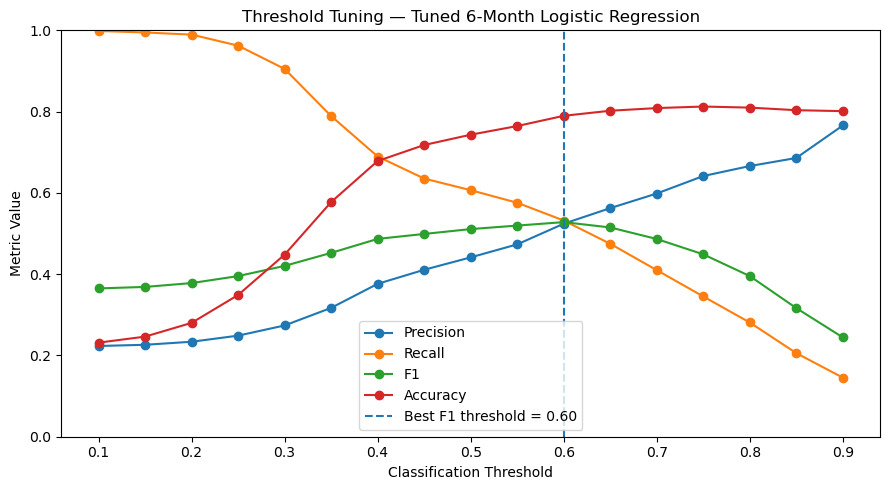


Confusion matrix at best threshold:
[[4032  641]
 [ 621  706]]


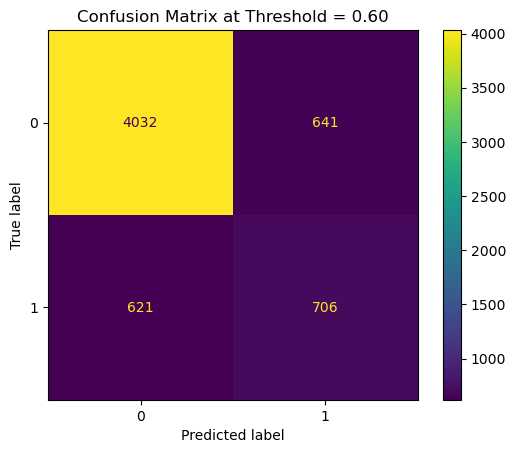

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ------------------------------------------------------------
# Recreate the held-out test set for the tuned 6-month model
# ------------------------------------------------------------

X_train_6m, X_test_6m, y_train_6m, y_test_6m = train_test_split(
    X_6m_sum,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Predicted probabilities from best tuned 6-month logistic model
y_score_6m = best_logit_6m.predict_proba(X_test_6m)[:, 1]

# ------------------------------------------------------------
# Evaluate many thresholds
# ------------------------------------------------------------

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_rows = []

for threshold in thresholds:
    y_pred_thresh = (y_score_6m >= threshold).astype(int)
    
    threshold_rows.append({
        "threshold": threshold,
        "Accuracy": accuracy_score(y_test_6m, y_pred_thresh),
        "Precision": precision_score(y_test_6m, y_pred_thresh, zero_division=0),
        "Recall": recall_score(y_test_6m, y_pred_thresh, zero_division=0),
        "F1": f1_score(y_test_6m, y_pred_thresh, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)

# ------------------------------------------------------------
# Find best threshold by F1
# ------------------------------------------------------------

best_idx = threshold_df["F1"].idxmax()
best_threshold_row = threshold_df.loc[best_idx]

print("Threshold tuning table:\n")
display(threshold_df.round(4))

print("\nBest threshold by F1:\n")
display(best_threshold_row.to_frame().T.round(4))

best_threshold = float(best_threshold_row["threshold"])
print(f"Chosen threshold: {best_threshold:.2f}")

# ------------------------------------------------------------
# Plot threshold vs metrics
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["F1"], marker="o", label="F1")
plt.plot(threshold_df["threshold"], threshold_df["Accuracy"], marker="o", label="Accuracy")
plt.axvline(best_threshold, linestyle="--", label=f"Best F1 threshold = {best_threshold:.2f}")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold Tuning — Tuned 6-Month Logistic Regression")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Show confusion matrix at the best threshold
# ------------------------------------------------------------

best_y_pred = (y_score_6m >= best_threshold).astype(int)
best_cm = confusion_matrix(y_test_6m, best_y_pred)

print("\nConfusion matrix at best threshold:")
print(best_cm)

disp = ConfusionMatrixDisplay(confusion_matrix=best_cm)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix at Threshold = {best_threshold:.2f}")
plt.show()

Brier score: 0.1900


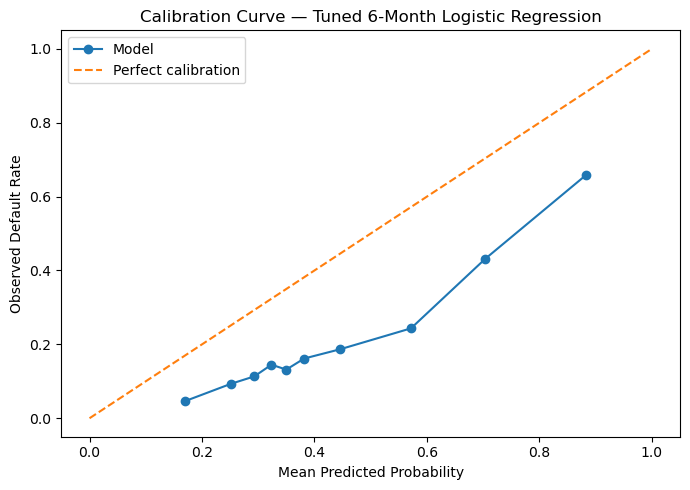


Probability binning table:


,prob_bin,accounts,observed_defaults,observed_default_rate,avg_predicted_prob
0,"(-0.0009715, 0.224]",600,28,0.0467,0.1704
1,"(0.224, 0.275]",600,56,0.0933,0.2516
2,"(0.275, 0.31]",600,68,0.1133,0.2931
3,"(0.31, 0.337]",600,87,0.1450,0.3235
4,"(0.337, 0.364]",600,79,0.1317,0.3499
5,"(0.364, 0.403]",600,97,0.1617,0.3817
6,"(0.403, 0.507]",600,112,0.1867,0.4455
7,"(0.507, 0.631]",600,146,0.2433,0.5716
8,"(0.631, 0.786]",600,259,0.4317,0.7038
9,"(0.786, 0.987]",600,395,0.6583,0.8829



Calibration table with gap:


,prob_bin,accounts,observed_defaults,observed_default_rate,avg_predicted_prob,calibration_gap
0,"(-0.0009715, 0.224]",600,28,0.0467,0.1704,-0.1238
1,"(0.224, 0.275]",600,56,0.0933,0.2516,-0.1583
2,"(0.275, 0.31]",600,68,0.1133,0.2931,-0.1797
3,"(0.31, 0.337]",600,87,0.1450,0.3235,-0.1785
4,"(0.337, 0.364]",600,79,0.1317,0.3499,-0.2182
5,"(0.364, 0.403]",600,97,0.1617,0.3817,-0.2200
6,"(0.403, 0.507]",600,112,0.1867,0.4455,-0.2588
7,"(0.507, 0.631]",600,146,0.2433,0.5716,-0.3283
8,"(0.631, 0.786]",600,259,0.4317,0.7038,-0.2721
9,"(0.786, 0.987]",600,395,0.6583,0.8829,-0.2246


In [22]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ------------------------------------------------------------
# Recreate the held-out test set for the tuned 6-month model
# ------------------------------------------------------------

X_train_6m, X_test_6m, y_train_6m, y_test_6m = train_test_split(
    X_6m_sum,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Predicted probabilities from best tuned 6-month logistic model
y_score_6m = best_logit_6m.predict_proba(X_test_6m)[:, 1]

# ------------------------------------------------------------
# Brier score
# ------------------------------------------------------------

brier = brier_score_loss(y_test_6m, y_score_6m)
print(f"Brier score: {brier:.4f}")

# ------------------------------------------------------------
# Calibration curve
# ------------------------------------------------------------

prob_true, prob_pred = calibration_curve(
    y_test_6m,
    y_score_6m,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve — Tuned 6-Month Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Probability-binning table
# ------------------------------------------------------------

calib_df = pd.DataFrame({
    "y_true": y_test_6m.values,
    "pred_prob": y_score_6m
})

# Use quantile bins so each bin has roughly similar counts
calib_df["prob_bin"] = pd.qcut(
    calib_df["pred_prob"],
    q=10,
    duplicates="drop"
)

calibration_table = calib_df.groupby("prob_bin").agg(
    accounts=("y_true", "size"),
    observed_defaults=("y_true", "sum"),
    observed_default_rate=("y_true", "mean"),
    avg_predicted_prob=("pred_prob", "mean")
).reset_index()

print("\nProbability binning table:")
display(calibration_table.round(4))

# ------------------------------------------------------------
# Simple calibration gap column
# ------------------------------------------------------------

calibration_table["calibration_gap"] = (
    calibration_table["observed_default_rate"] - calibration_table["avg_predicted_prob"]
)

print("\nCalibration table with gap:")
display(calibration_table.round(4))

In [24]:
# ------------------------------------------------------------
# Pull core numbers from earlier cells
# ------------------------------------------------------------

best_window_row = results_df.sort_values("ROC_AUC", ascending=False).iloc[0]
best_window = best_window_row["window"]
best_window_roc = best_window_row["ROC_AUC"]
best_window_pr = best_window_row["PR_AUC"]

best_rule_row = rule_results_df.sort_values("F1", ascending=False).iloc[0]
best_rule_name = best_rule_row["rule"]
best_rule_f1 = best_rule_row["F1"]

best_logit_f1_row = results_df.sort_values("F1", ascending=False).iloc[0]
best_logit_f1 = best_logit_f1_row["F1"]
best_logit_f1_window = best_logit_f1_row["window"]

roc_gain_vs_rule = np.nan
if not pd.isna(best_window_roc):
    roc_gain_vs_rule = best_window_roc

# Raw vs summary comparison, if Cell 16 was run
raw_vs_summary_available = "raw_vs_summary_df" in globals()

summary_advantage_lines = []
if raw_vs_summary_available:
    for window in ["1 month", "3 months", "6 months"]:
        sub = raw_vs_summary_df[raw_vs_summary_df["window"] == window].copy()
        if len(sub) == 2:
            raw_roc = sub.loc[sub["feature_type"] == "raw", "ROC_AUC"].values[0]
            sum_roc = sub.loc[sub["feature_type"] == "summary", "ROC_AUC"].values[0]
            diff = sum_roc - raw_roc
            if diff > 0:
                summary_advantage_lines.append(
                    f"For the {window} window, summary features outperformed raw features in ROC-AUC by {diff:.4f}."
                )
            elif diff < 0:
                summary_advantage_lines.append(
                    f"For the {window} window, raw features outperformed summary features in ROC-AUC by {abs(diff):.4f}."
                )
            else:
                summary_advantage_lines.append(
                    f"For the {window} window, raw and summary features had the same ROC-AUC."
                )

# Threshold tuning, if Cell 17 was run
threshold_text = None
if "best_threshold_row" in globals():
    threshold_text = (
        f"Threshold tuning suggested an operating threshold of "
        f"{best_threshold_row['threshold']:.2f}, which produced "
        f"Precision = {best_threshold_row['Precision']:.4f}, "
        f"Recall = {best_threshold_row['Recall']:.4f}, and "
        f"F1 = {best_threshold_row['F1']:.4f}."
    )

# Early warning result, if Cell 10 was run
early_warning_text = None
if "subset_roc_auc" in globals() and "subset_pr_auc" in globals():
    early_warning_text = (
        f"On the non-obvious-risk subset (PAY_0 < 2), the tuned 6-month logistic model "
        f"achieved ROC-AUC = {subset_roc_auc:.4f} and PR-AUC = {subset_pr_auc:.4f}. "
        f"This indicates the model retains predictive power even before obvious current delinquency spikes."
    )

# Calibration result, if Cell 18 was run
calibration_text = None
if "brier" in globals():
    calibration_text = f"The model's Brier score was {brier:.4f}, providing a summary measure of probability calibration."

# Lift result, if Cell 15 was run
lift_text = None
if "lift_at_10" in globals() and "capture_rate_top10" in globals():
    lift_text = (
        f"In the top predicted-risk decile, the model achieved a lift of {lift_at_10:.4f} "
        f"and captured {capture_rate_top10:.4f} of all defaults in the held-out test set."
    )

# ------------------------------------------------------------
# Build a report-ready findings list
# ------------------------------------------------------------

findings = []

findings.append(
    f"The strongest logistic regression time window was {best_window} "
    f"(ROC-AUC = {best_window_roc:.4f}, PR-AUC = {best_window_pr:.4f})."
)

findings.append(
    f"The best traditional rule baseline was '{best_rule_name}', with F1 = {best_rule_f1:.4f}."
)

findings.append(
    f"The best logistic regression model by F1 used the {best_logit_f1_window} window "
    f"and achieved F1 = {best_logit_f1:.4f}."
)

if early_warning_text is not None:
    findings.append(early_warning_text)

if lift_text is not None:
    findings.append(lift_text)

if calibration_text is not None:
    findings.append(calibration_text)

if threshold_text is not None:
    findings.append(threshold_text)

findings.extend(summary_advantage_lines)

# ------------------------------------------------------------
# Display findings cleanly
# ------------------------------------------------------------

print("Report-Ready Key Findings")
print("=" * 60)

for i, finding in enumerate(findings, start=1):
    print(f"{i}. {finding}")

# ------------------------------------------------------------
# Save findings to a DataFrame for easy export/copying
# ------------------------------------------------------------

findings_df = pd.DataFrame({
    "finding_number": range(1, len(findings) + 1),
    "finding_text": findings
})

print("\nFindings table:")
display(findings_df)

# ------------------------------------------------------------
# create a single paragraph version
# ------------------------------------------------------------

summary_paragraph = " ".join(findings)

print("\nSingle-paragraph summary:\n")
print(summary_paragraph)

Report-Ready Key Findings
1. The strongest logistic regression time window was 3 months (ROC-AUC = 0.7571, PR-AUC = 0.5156).
2. The best traditional rule baseline was 'recent_any_delinquency (PAY_0 >= 1)', with F1 = 0.5097.
3. The best logistic regression model by F1 used the 3 months window and achieved F1 = 0.5181.
4. On the non-obvious-risk subset (PAY_0 < 2), the tuned 6-month logistic model achieved ROC-AUC = 0.6754 and PR-AUC = 0.3058. This indicates the model retains predictive power even before obvious current delinquency spikes.
5. In the top predicted-risk decile, the model achieved a lift of 2.9766 and captured 0.2977 of all defaults in the held-out test set.
6. The model's Brier score was 0.1900, providing a summary measure of probability calibration.
7. Threshold tuning suggested an operating threshold of 0.60, which produced Precision = 0.5241, Recall = 0.5320, and F1 = 0.5280.
8. For the 1 month window, summary features outperformed raw features in ROC-AUC by 0.0314.
9. 

,finding_number,finding_text
0,1,The strongest logistic regression time window ...
1,2,The best traditional rule baseline was 'recent...
2,3,The best logistic regression model by F1 used ...
3,4,"On the non-obvious-risk subset (PAY_0 < 2), th..."
4,5,"In the top predicted-risk decile, the model ac..."
5,6,"The model's Brier score was 0.1900, providing ..."
6,7,Threshold tuning suggested an operating thresh...
7,8,"For the 1 month window, summary features outpe..."
8,9,"For the 3 months window, summary features outp..."
9,10,"For the 6 months window, summary features outp..."



Single-paragraph summary:

The strongest logistic regression time window was 3 months (ROC-AUC = 0.7571, PR-AUC = 0.5156). The best traditional rule baseline was 'recent_any_delinquency (PAY_0 >= 1)', with F1 = 0.5097. The best logistic regression model by F1 used the 3 months window and achieved F1 = 0.5181. On the non-obvious-risk subset (PAY_0 < 2), the tuned 6-month logistic model achieved ROC-AUC = 0.6754 and PR-AUC = 0.3058. This indicates the model retains predictive power even before obvious current delinquency spikes. In the top predicted-risk decile, the model achieved a lift of 2.9766 and captured 0.2977 of all defaults in the held-out test set. The model's Brier score was 0.1900, providing a summary measure of probability calibration. Threshold tuning suggested an operating threshold of 0.60, which produced Precision = 0.5241, Recall = 0.5320, and F1 = 0.5280. For the 1 month window, summary features outperformed raw features in ROC-AUC by 0.0314. For the 3 months window, 

CREDIT DEFAULT EARLY-WARNING PROJECT — SUMMARY DASHBOARD

TOP FINDINGS
--------------------------------------------------------------------------------


,finding_number,finding_text
0,1,The strongest logistic regression time window ...
1,2,The best traditional rule baseline was 'recent...
2,3,The best logistic regression model by F1 used ...
3,4,"On the non-obvious-risk subset (PAY_0 < 2), th..."
4,5,"In the top predicted-risk decile, the model ac..."
5,6,"The model's Brier score was 0.1900, providing ..."
6,7,Threshold tuning suggested an operating thresh...
7,8,"For the 1 month window, summary features outpe..."
8,9,"For the 3 months window, summary features outp..."
9,10,"For the 6 months window, summary features outp..."



LOGISTIC REGRESSION BY TIME WINDOW
--------------------------------------------------------------------------------


,window,best_penalty,best_C,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1
0,3 months,l1,1.0,0.7571,0.5156,0.7672,0.4777,0.5659,0.5181
1,6 months,l1,0.1,0.7558,0.5174,0.7432,0.4413,0.6066,0.5109
2,1 month,l1,1.0,0.7337,0.4917,0.7730,0.4872,0.5034,0.4952



TRADITIONAL RULE-BASED BASELINES
--------------------------------------------------------------------------------


...

,threshold,Accuracy,Precision,Recall,F1
0,0.10,0.2315,0.2233,0.9985,0.3650
1,0.15,0.2463,0.2262,0.9947,0.3686
2,0.20,0.2802,0.2337,0.9894,0.3781
3,0.25,0.3488,0.2487,0.9623,0.3953
4,0.30,0.4482,0.2738,0.9050,0.4204
5,0.35,0.5775,0.3171,0.7890,0.4524
6,0.40,0.6785,0.3762,0.6895,0.4868
7,0.45,0.7178,0.4108,0.6353,0.4990
8,0.50,0.7432,0.4413,0.6066,0.5109
9,0.55,0.7645,0.4734,0.5757,0.5196



CALIBRATION TABLE
--------------------------------------------------------------------------------


,prob_bin,accounts,observed_defaults,observed_default_rate,avg_predicted_prob,calibration_gap
0,"(-0.0009715, 0.224]",600,28,0.0467,0.1704,-0.1238
1,"(0.224, 0.275]",600,56,0.0933,0.2516,-0.1583
2,"(0.275, 0.31]",600,68,0.1133,0.2931,-0.1797
3,"(0.31, 0.337]",600,87,0.1450,0.3235,-0.1785
4,"(0.337, 0.364]",600,79,0.1317,0.3499,-0.2182
5,"(0.364, 0.403]",600,97,0.1617,0.3817,-0.2200
6,"(0.403, 0.507]",600,112,0.1867,0.4455,-0.2588
7,"(0.507, 0.631]",600,146,0.2433,0.5716,-0.3283
8,"(0.631, 0.786]",600,259,0.4317,0.7038,-0.2721
9,"(0.786, 0.987]",600,395,0.6583,0.8829,-0.2246



DECILE LIFT SUMMARY
--------------------------------------------------------------------------------


,decile,accounts,defaults,default_rate,avg_score
0,1,600,395,0.6583,0.8829
1,2,600,259,0.4317,0.7038
2,3,600,146,0.2433,0.5716
3,4,600,112,0.1867,0.4455
4,5,600,97,0.1617,0.3817
5,6,600,79,0.1317,0.3499
6,7,600,87,0.1450,0.3235
7,8,600,68,0.1133,0.2931
8,9,600,56,0.0933,0.2516
9,10,600,28,0.0467,0.1704


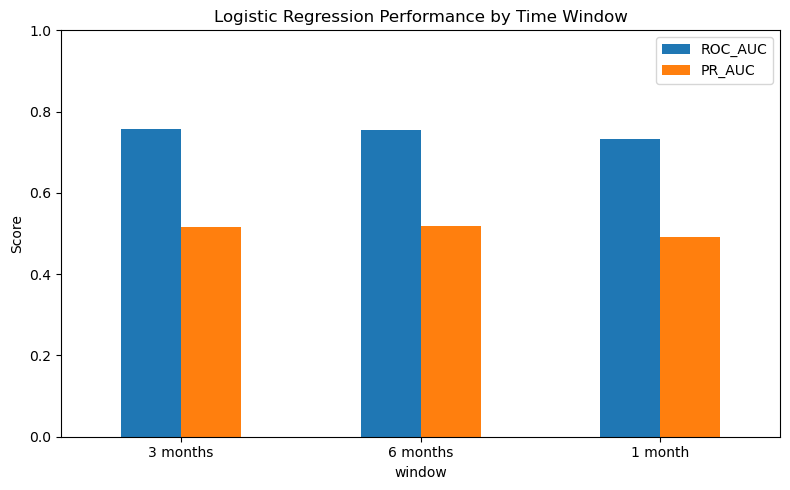

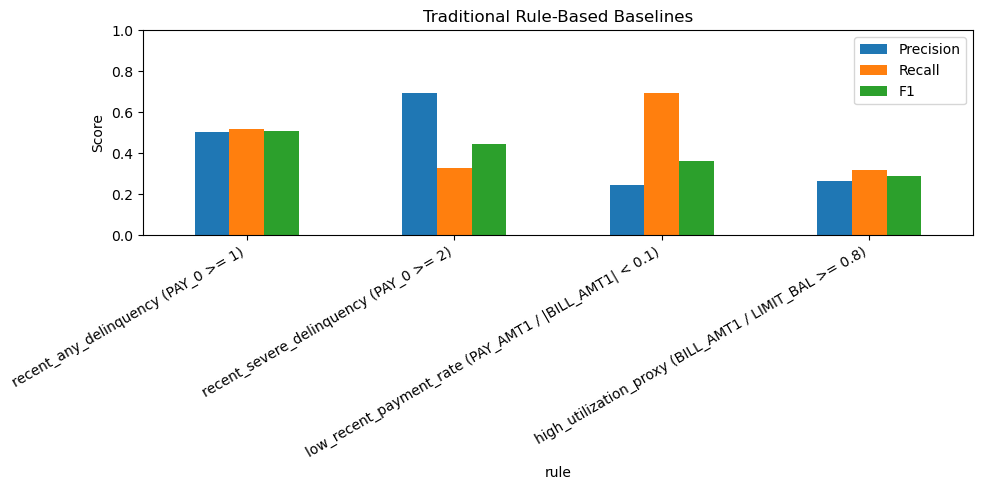

/var/folders/kv/x1tlq9x13tlg0cfbv5_tq90c0000gn/T/ipykernel_36366/1487311149.py:144: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=35, ha="right")


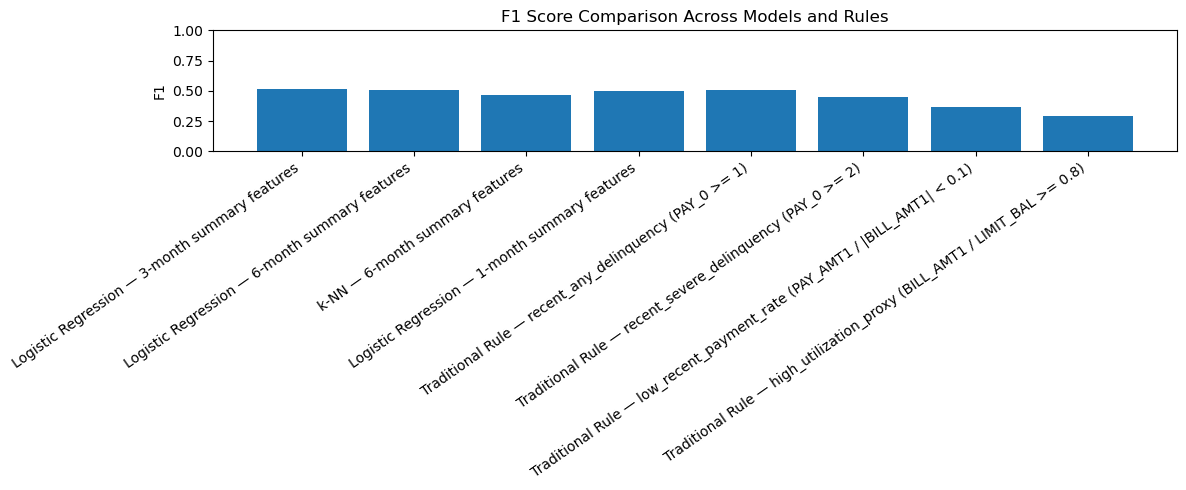

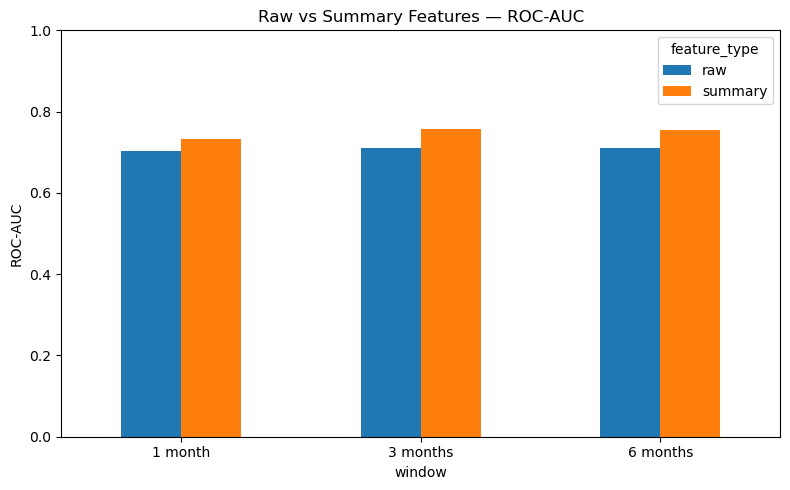

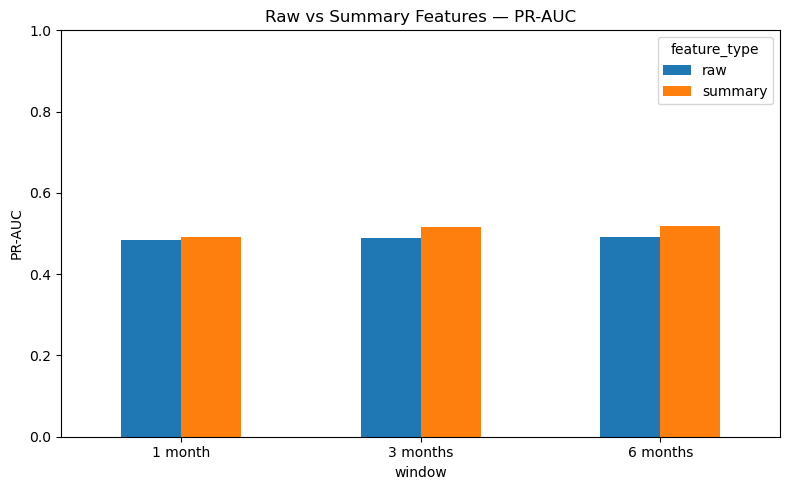

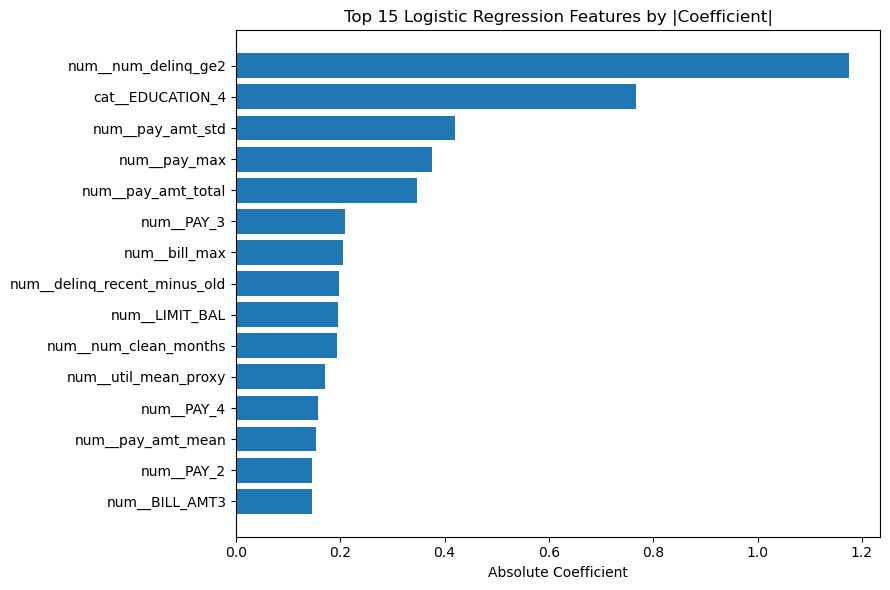

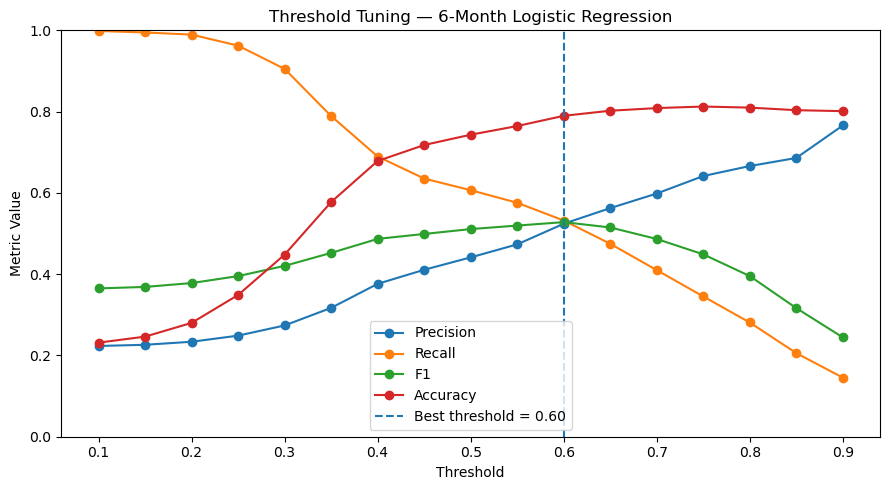

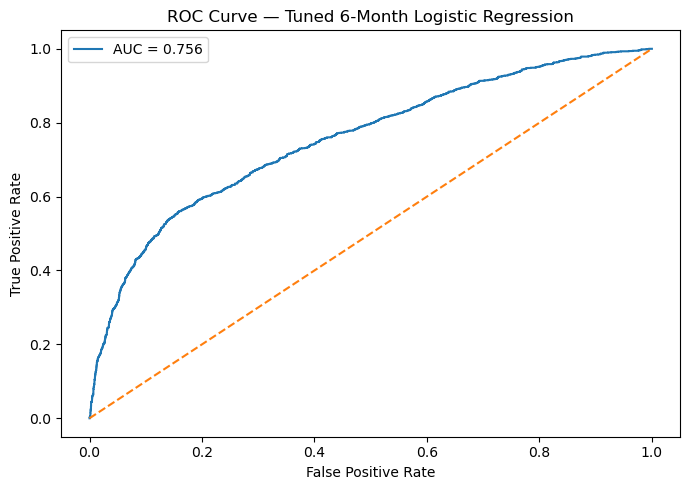

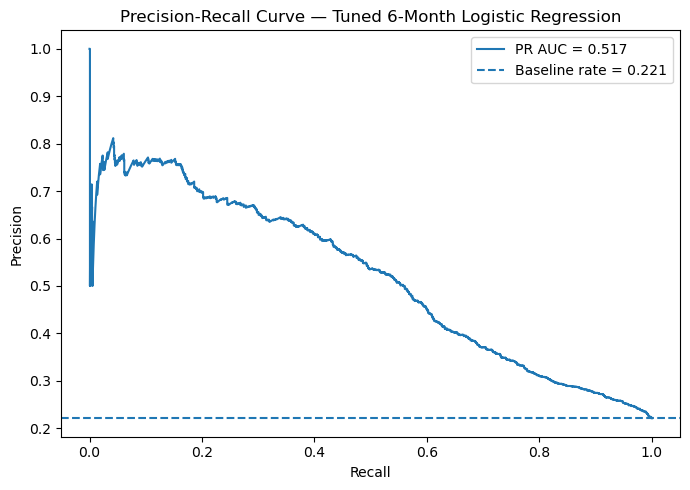

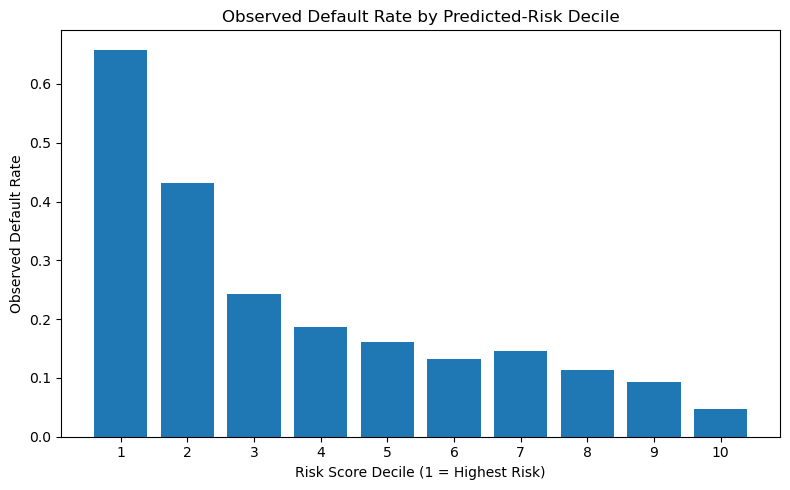

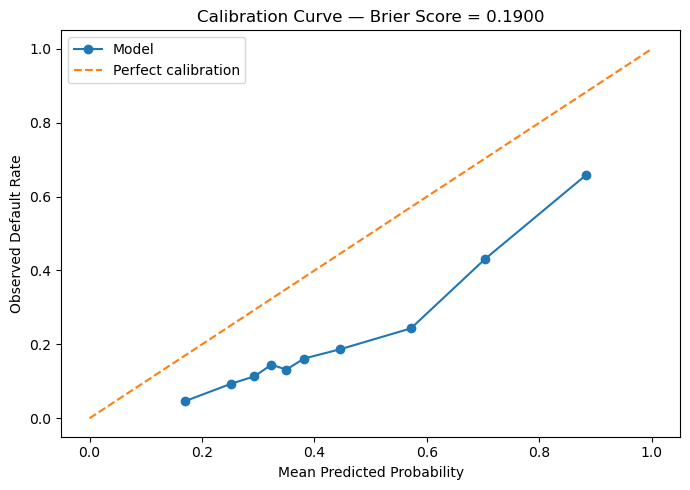


SUMMARY DASHBOARD COMPLETE


In [25]:
# ============================================================
# SUMMARY DASHBOARD CELL — Consolidated Results, Tables, and Charts
# ============================================================

import matplotlib.pyplot as plt

print("=" * 80)
print("CREDIT DEFAULT EARLY-WARNING PROJECT — SUMMARY DASHBOARD")
print("=" * 80)

# ------------------------------------------------------------
# 1. Best high-level findings
# ------------------------------------------------------------

if "findings_df" in globals():
    print("\nTOP FINDINGS")
    print("-" * 80)
    display(findings_df)
elif "summary_paragraph" in globals():
    print("\nTOP FINDINGS")
    print("-" * 80)
    print(summary_paragraph)

# ------------------------------------------------------------
# 2. Core model comparison tables
# ------------------------------------------------------------

if "results_df" in globals():
    print("\nLOGISTIC REGRESSION BY TIME WINDOW")
    print("-" * 80)
    display(results_df.round(4))

if "rule_results_df" in globals():
    print("\nTRADITIONAL RULE-BASED BASELINES")
    print("-" * 80)
    display(rule_results_df.round(4))

if "final_results_df" in globals():
    print("\nFINAL MODEL COMPARISON TABLE")
    print("-" * 80)
    display(final_results_df.round(4))

if "final_results_with_knn_df" in globals():
    print("\nFINAL MODEL COMPARISON TABLE (INCLUDING k-NN)")
    print("-" * 80)
    display(final_results_with_knn_df.round(4))

if "raw_vs_summary_df" in globals():
    print("\nRAW VS SUMMARY FEATURE COMPARISON")
    print("-" * 80)
    display(raw_vs_summary_df.round(4))

# ------------------------------------------------------------
# 3. Early-warning summary
# ------------------------------------------------------------

if "subset_roc_auc" in globals():
    print("\nEARLY-WARNING TEST: NON-OBVIOUS-RISK SUBSET (PAY_0 < 2)")
    print("-" * 80)
    print(f"Subset ROC-AUC: {subset_roc_auc:.4f}")
    print(f"Subset PR-AUC:  {subset_pr_auc:.4f}")
    if "subset_size" in globals():
        print(f"Subset size:    {subset_size}")
    if "subset_default_rate" in globals():
        print(f"Default rate:   {subset_default_rate:.4f}")

# ------------------------------------------------------------
# 4. Most influential logistic features
# ------------------------------------------------------------

if "coef_df" in globals():
    print("\nTOP 20 LOGISTIC REGRESSION FEATURES")
    print("-" * 80)
    display(coef_df.head(20).round(4))

# ------------------------------------------------------------
# 5. Threshold tuning table
# ------------------------------------------------------------

if "threshold_df" in globals():
    print("\nTHRESHOLD TUNING RESULTS")
    print("-" * 80)
    display(threshold_df.round(4))

# ------------------------------------------------------------
# 6. Calibration and lift tables
# ------------------------------------------------------------

if "calibration_table" in globals():
    print("\nCALIBRATION TABLE")
    print("-" * 80)
    display(calibration_table.round(4))

if "decile_summary" in globals():
    print("\nDECILE LIFT SUMMARY")
    print("-" * 80)
    display(decile_summary.round(4))

# ============================================================
# CHARTS / FIGURES
# ============================================================

# ------------------------------------------------------------
# Figure 1: Logistic regression performance by time window
# ------------------------------------------------------------

if "results_df" in globals():
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_df = results_df.set_index("window")[["ROC_AUC", "PR_AUC"]]
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title("Logistic Regression Performance by Time Window")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Figure 2: Traditional rule-based baselines
# ------------------------------------------------------------

if "rule_results_df" in globals():
    fig, ax = plt.subplots(figsize=(10, 5))
    tmp = rule_results_df.copy().set_index("rule")[["Precision", "Recall", "F1"]]
    tmp.plot(kind="bar", ax=ax)
    ax.set_title("Traditional Rule-Based Baselines")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Figure 3: Final F1 comparison across all models
# ------------------------------------------------------------

if "final_results_with_knn_df" in globals():
    fig, ax = plt.subplots(figsize=(12, 5))
    labels = final_results_with_knn_df["model_type"] + " — " + final_results_with_knn_df["model_name"]
    ax.bar(labels, final_results_with_knn_df["F1"])
    ax.set_title("F1 Score Comparison Across Models and Rules")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
elif "final_results_df" in globals():
    fig, ax = plt.subplots(figsize=(12, 5))
    labels = final_results_df["model_type"] + " — " + final_results_df["model_name"]
    ax.bar(labels, final_results_df["F1"])
    ax.set_title("F1 Score Comparison Across Models and Rules")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Figure 4: Raw vs summary features
# ------------------------------------------------------------

if "raw_vs_summary_df" in globals():
    roc_pivot = raw_vs_summary_df.pivot(index="window", columns="feature_type", values="ROC_AUC")
    pr_pivot = raw_vs_summary_df.pivot(index="window", columns="feature_type", values="PR_AUC")

    fig, ax = plt.subplots(figsize=(8, 5))
    roc_pivot.plot(kind="bar", ax=ax)
    ax.set_title("Raw vs Summary Features — ROC-AUC")
    ax.set_ylabel("ROC-AUC")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    pr_pivot.plot(kind="bar", ax=ax)
    ax.set_title("Raw vs Summary Features — PR-AUC")
    ax.set_ylabel("PR-AUC")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Figure 5: Coefficient importance (top 15)
# ------------------------------------------------------------

if "coef_df" in globals():
    top_coef = coef_df.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top_coef["feature"], top_coef["abs_coefficient"])
    ax.set_title("Top 15 Logistic Regression Features by |Coefficient|")
    ax.set_xlabel("Absolute Coefficient")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Figure 6: Threshold tuning curves
# ------------------------------------------------------------

if "threshold_df" in globals():
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(threshold_df["threshold"], threshold_df["Precision"], marker="o", label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["Recall"], marker="o", label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["F1"], marker="o", label="F1")
    ax.plot(threshold_df["threshold"], threshold_df["Accuracy"], marker="o", label="Accuracy")

    if "best_threshold" in globals():
        ax.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.2f}")

    ax.set_title("Threshold Tuning — 6-Month Logistic Regression")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric Value")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Figure 7: ROC and PR curves
# ------------------------------------------------------------

if "X_6m_sum" in globals() and "best_logit_6m" in globals():
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_curve, precision_recall_curve, auc

    X_train_6m_dash, X_test_6m_dash, y_train_6m_dash, y_test_6m_dash = train_test_split(
        X_6m_sum,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    y_score_dash = best_logit_6m.predict_proba(X_test_6m_dash)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test_6m_dash, y_score_dash)
    roc_auc_val = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title("ROC Curve — Tuned 6-Month Logistic Regression")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # PR
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_6m_dash, y_score_dash)
    pr_auc_val = auc(recall_vals, precision_vals)
    baseline_rate = y_test_6m_dash.mean()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc_val:.3f}")
    ax.axhline(baseline_rate, linestyle="--", label=f"Baseline rate = {baseline_rate:.3f}")
    ax.set_title("Precision-Recall Curve — Tuned 6-Month Logistic Regression")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Figure 8: Top-decile / decile default-rate chart
# ------------------------------------------------------------

if "decile_summary" in globals():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(decile_summary["decile"].astype(str), decile_summary["default_rate"])
    ax.set_title("Observed Default Rate by Predicted-Risk Decile")
    ax.set_xlabel("Risk Score Decile (1 = Highest Risk)")
    ax.set_ylabel("Observed Default Rate")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Figure 9: Calibration curve
# ------------------------------------------------------------

if "X_6m_sum" in globals() and "best_logit_6m" in globals():
    from sklearn.calibration import calibration_curve
    from sklearn.metrics import brier_score_loss

    X_train_6m_cal, X_test_6m_cal, y_train_6m_cal, y_test_6m_cal = train_test_split(
        X_6m_sum,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    y_score_cal = best_logit_6m.predict_proba(X_test_6m_cal)[:, 1]
    prob_true, prob_pred = calibration_curve(
        y_test_6m_cal,
        y_score_cal,
        n_bins=10,
        strategy="quantile"
    )
    brier_val = brier_score_loss(y_test_6m_cal, y_score_cal)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(prob_pred, prob_true, marker="o", label="Model")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    ax.set_title(f"Calibration Curve — Brier Score = {brier_val:.4f}")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Default Rate")
    ax.legend()
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
print("SUMMARY DASHBOARD COMPLETE")
print("=" * 80)

KEY FINDINGS TABLE


,model_type,model_name,ROC_AUC,PR_AUC,Recall,F1
0,Logistic Regression,3-month summary features,0.7571,0.5156,0.5659,0.5181
1,Logistic Regression,6-month summary features,0.7558,0.5174,0.6066,0.5109
2,k-NN,6-month summary features,0.7544,0.5122,0.3632,0.4644
3,Logistic Regression,1-month summary features,0.7337,0.4917,0.5034,0.4952
4,Traditional Rule,recent_any_delinquency (PAY_0 >= 1),NaN,NaN,0.5167,0.5097
5,Traditional Rule,recent_severe_delinquency (PAY_0 >= 2),NaN,NaN,0.3281,0.4458
6,Traditional Rule,low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1...,NaN,NaN,0.6924,0.3649
7,Traditional Rule,high_utilization_proxy (BILL_AMT1 / LIMIT_BAL ...,NaN,NaN,0.3214,0.2919


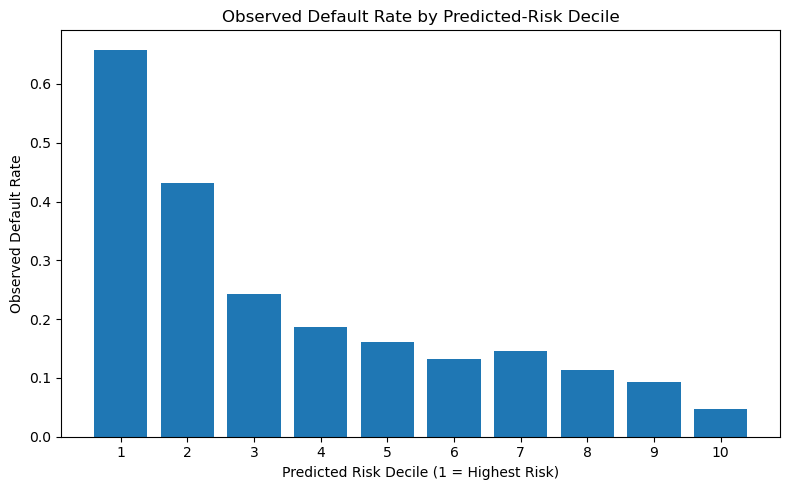

In [26]:
# ============================================================
# KEY FINDINGS — 1 TABLE + 1 GRAPH
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# TABLE: key model comparison table
# ------------------------------------------------------------

# Prefer final table with k-NN if available, otherwise use final_results_df
if "final_results_with_knn_df" in globals():
    key_table_df = final_results_with_knn_df.copy()
elif "final_results_df" in globals():
    key_table_df = final_results_df.copy()
else:
    # fallback: build a compact table from logistic results only
    key_table_df = pd.DataFrame([
        {
            "model_type": "Logistic Regression",
            "model_name": "1-month summary features",
            "ROC_AUC": results_1m["ROC_AUC"],
            "PR_AUC": results_1m["PR_AUC"],
            "Accuracy": results_1m["Accuracy"],
            "Precision": results_1m["Precision"],
            "Recall": results_1m["Recall"],
            "F1": results_1m["F1"]
        },
        {
            "model_type": "Logistic Regression",
            "model_name": "3-month summary features",
            "ROC_AUC": results_3m["ROC_AUC"],
            "PR_AUC": results_3m["PR_AUC"],
            "Accuracy": results_3m["Accuracy"],
            "Precision": results_3m["Precision"],
            "Recall": results_3m["Recall"],
            "F1": results_3m["F1"]
        },
        {
            "model_type": "Logistic Regression",
            "model_name": "6-month summary features",
            "ROC_AUC": results_6m["ROC_AUC"],
            "PR_AUC": results_6m["PR_AUC"],
            "Accuracy": results_6m["Accuracy"],
            "Precision": results_6m["Precision"],
            "Recall": results_6m["Recall"],
            "F1": results_6m["F1"]
        }
    ])

# Keep only the most important columns
key_table_df = key_table_df.copy()
key_table_df = key_table_df[[
    "model_type", "model_name", "ROC_AUC", "PR_AUC", "Recall", "F1"
]]

# Sort best to worst
if "ROC_AUC" in key_table_df.columns:
    key_table_df = key_table_df.sort_values(by="ROC_AUC", ascending=False, na_position="last").reset_index(drop=True)

print("KEY FINDINGS TABLE")
display(key_table_df.round(4))

# ------------------------------------------------------------
# GRAPH: observed default rate by predicted-risk decile
# ------------------------------------------------------------

# If decile_summary already exists, use it
if "decile_summary" not in globals():
    # recreate from tuned 6-month logistic model
    from sklearn.model_selection import train_test_split

    X_train_6m, X_test_6m, y_train_6m, y_test_6m = train_test_split(
        X_6m_sum,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    y_score_6m = best_logit_6m.predict_proba(X_test_6m)[:, 1]

    lift_df = pd.DataFrame({
        "y_true": y_test_6m.values,
        "score": y_score_6m
    }).sort_values("score", ascending=False).reset_index(drop=True)

    lift_df["decile"] = pd.qcut(
        lift_df["score"].rank(method="first", ascending=False),
        10,
        labels=[1,2,3,4,5,6,7,8,9,10]
    )

    decile_summary = lift_df.groupby("decile").agg(
        accounts=("y_true", "size"),
        defaults=("y_true", "sum"),
        default_rate=("y_true", "mean"),
        avg_score=("score", "mean")
    ).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(decile_summary["decile"].astype(str), decile_summary["default_rate"])
plt.xlabel("Predicted Risk Decile (1 = Highest Risk)")
plt.ylabel("Observed Default Rate")
plt.title("Observed Default Rate by Predicted-Risk Decile")
plt.tight_layout()
plt.show()